# Chess Rating Systems: Building and Comparing Elo & Glicko-2

**Author:** Atilla Ahmed.
**Data Sources:** Lichess Game Database (Kaggle) · FIDE Official Rating Lists

## Table of Content

1. Introduction
2. Data Loading & Initial Inspection
3. Data Cleaning & Preprocessing
4. Exploratory Data Analysis
5. Mathematical Framework
6. Implementation
7. Hypothesis Testing
8. Conclusion
9. Self-Assessment

---

## 1. Introduction

### 1.1 Motivation

I play chess online and I've always been curious about what the rating number actually means mathematically. The **Elo system**, introduced in the 1960s by Arpad Elo and adopted by FIDE in 1970, uses a logistic function to estimate the probability that one player beats another based on their rating difference. It's simple and widely used, but it has a weakness it doesn't track how *certain* the system is about a player's rating.

**Glicko-2** (Glickman, 2001) solves this by adding a rating deviation (uncertainty) and a volatility parameter per player. Lichess uses Glicko-2; FIDE still uses Elo. In this project I derive both systems from scratch, implement them in Python, and test them on real data.

### 1.2 Problem Statement & Objectives

> **How well do Elo and Glicko-2 predict chess outcomes, and what do online (Lichess) and over-the-board (FIDE) data reveal about how ratings behave in practice?**

Specific questions I want to answer:

1. How well-calibrated is the Elo prediction? (If the model says 70% win chance, does white win ~70% of the time?)
2. Is white's first-move advantage statistically significant, and does it vary by rating level?
3. Do certain openings produce significantly different win rates?
4. How do Lichess and FIDE rating distributions compare structurally?
5. Is there a gender gap in FIDE ratings, and can participation rates explain it?
6. Can a logistic regression model that includes color, opening, and time control outperform pure Elo?

Each of these is formalized as a hypothesis test or model comparison in Sections 6–7.

The project has three goals: derive the math behind Elo and Glicko-2 with full formulas, implement both from scratch (no pre-built rating libraries), and run statistical analysis on real data from two independent sources.

### 1.3 Data Sources

**Lichess (Kaggle)** - 20,000+ online games in CSV format. Each row is a game with both players' ratings, the result, opening name/ECO code, number of moves, and time control. Licensed CC0.

**FIDE (ratings.fide.com)** - official rating list in fixed-width TXT. Each row is a player with Standard/Rapid/Blitz ratings, title, federation, gender, and birth year.

The two datasets can't be merged at the player level (no shared ID), but I compare them at the aggregate level, distribution shapes, population parameters, and how the Elo formula performs in each context.

### 1.4 Prior Work

Elo described his system in *The Rating of Chessplayers, Past and Present* (1978). Glickman published Glicko-2 in 2001 — his paper *"Example of the Glicko-2 System"* is the main reference I follow for the implementation. There's also ML-based approaches (logistic regression, gradient boosting) that can outperform Elo in raw accuracy, but I'm more interested in understanding the mathematical structure than maximizing a metric.

## 2. Data Loading and Initial Inspection
This section Loads both datasets, check their structure, and flags anything that need attention before the real analysis. The Lichess data comes as a standard CSV with one row per game. The FIDE data is a fixed-width text file a snapshot of every registered player with their current ratings.

### 2.0 Setup and Imports

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, shapiro, binomtest

### 2.1 Loading the Lichess Dataset
The Lichess data is a CSV from Kaggle containing ~20,000 games played.


In [2]:
lichess = pd.read_csv('games.csv')
# Let's look the shape
print(f'Shape: {lichess.shape[0]:,} rows x {lichess.shape[1]:,} columns ')
print()

# Columns types and non-null counts
lichess.info()

Shape: 20,058 rows x 16 columns 

<class 'pandas.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  str    
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  str    
 6   winner          20058 non-null  str    
 7   increment_code  20058 non-null  str    
 8   white_id        20058 non-null  str    
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  str    
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  str    
 13  opening_eco     20058 non-null  str    
 14  opening_name    20058 non-null  str    
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), str(9)
memory usage

In [3]:
# Preview first 5 rows
lichess.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [4]:
# Statistics for Numerical Columns
lichess.describe().T

,count,mean,std,min,25%,50%,75%,max
created_at,20058.0,1.483617e+12,2.850151e+10,1.376772e+12,1.477548e+12,1.496010e+12,1.503170e+12,1.504493e+12
last_move_at,20058.0,1.483618e+12,2.850140e+10,1.376772e+12,1.477548e+12,1.496010e+12,1.503170e+12,1.504494e+12
turns,20058.0,6.046600e+01,3.357058e+01,1.000000e+00,3.700000e+01,5.500000e+01,7.900000e+01,3.490000e+02
white_rating,20058.0,1.596632e+03,2.912534e+02,7.840000e+02,1.398000e+03,1.567000e+03,1.793000e+03,2.700000e+03
black_rating,20058.0,1.588832e+03,2.910361e+02,7.890000e+02,1.391000e+03,1.562000e+03,1.784000e+03,2.723000e+03
opening_ply,20058.0,4.816981e+00,2.797152e+00,1.000000e+00,3.000000e+00,4.000000e+00,6.000000e+00,2.800000e+01


Check for missing values the '.info()' above showed all columns as non-null, but i will check to confirm is everything is okay.

In [5]:
missing_lichess = lichess.isnull().sum()
missing_pct = (missing_lichess / len(lichess)) * 100 # as percentage of total

# Now display columns with missing values (if any)
missing_df = pd.DataFrame({
    'Missing': missing_lichess,
    'Percentage': missing_pct
})
missing_df[missing_df['Missing'] > 0] # Filtering to show only problematic columns
# If this table is empty - no missing data at all

,Missing,Percentage


Unique values for key categorical columns, this tells me how many distinct players, openings, and result types exists:

In [6]:
cat_cols = ['winner', 'victory_status', 'increment_code', 'opening_eco', 'opening_name']
for col in cat_cols:
    n_unique = lichess[col].nunique() # count distinct values
    top_val = lichess[col].value_counts().index[0] # most frequent value
    top_pct = lichess[col].value_counts(normalize=True).iloc[0] * 100
    print(f'{col:20s} → {n_unique:>5,} unique | most common: "{top_val}" ({top_pct:.1f}%)')

winner               →     3 unique | most common: "white" (49.9%)
victory_status       →     4 unique | most common: "resign" (55.6%)
increment_code       →   400 unique | most common: "10+0" (38.5%)
opening_eco          →   365 unique | most common: "A00" (5.0%)
opening_name         → 1,477 unique | most common: "Van't Kruijs Opening" (1.8%)


### 2.2 Loading the FIDE Dataset
The FIDE data is a rating list snapshot from ratings.fide.com with ~1.8 million registered players. Each row is one player with their Standard, Rapid, and Blitz Elo ratings, plus metadata like title, federation, gender, and birth year. The column names use FIDE's standard abbreviations — I'll rename them for clarity.

In [7]:
fide = pd.read_fwf('players_list_foa.txt')
print(f'Shape: {fide.shape[0]:,} rows x {fide.shape[1]:,} columns ')
print()

print('Columns:', list(fide.columns))
print()

print(fide.dtypes)


Shape: 1,816,699 rows x 19 columns 

Columns: ['ID Number', 'Name', 'Fed', 'Sex', 'Tit', 'WTit', 'OTit', 'FOA', 'SRtng', 'SGm', 'SK', 'RRtng', 'RGm', 'Rk', 'BRtng', 'BGm', 'BK', 'B-day', 'Flag']

ID Number    int64
Name           str
Fed            str
Sex            str
Tit            str
WTit           str
OTit           str
FOA            str
SRtng        int64
SGm          int64
SK           int64
RRtng        int64
RGm          int64
Rk           int64
BRtng        int64
BGm          int64
BK           int64
B-day        int64
Flag           str
dtype: object


FIDE uses cryptic column abbreviations. Here's what each one means, i'll rename some of them later for readability:

| Column | Meaning |
|--------|---------|
| `SRtng` / `SGm` / `SK` | Standard rating, games, K-factor |
| `RRtng` / `RGm` / `Rk` | Rapid rating, games, K-factor |
| `BRtng` / `BGm` / `BK` | Blitz rating, games, K-factor |
| `Tit` | FIDE title (GM, IM, FM, CM, WGM, ...) |
| `WTit` | Women's title |
| `Fed` | Federation (country code, e.g. BUL, USA, RUS) |
| `B-day` | Birth year |
| `Flag` | Activity flag (i = inactive, w = woman-inactive, etc.) |

In [8]:
# First 5 rows:
fide.head()

,ID Number,Name,Fed,Sex,Tit,WTit,OTit,FOA,SRtng,SGm,SK,RRtng,RGm,Rk,BRtng,BGm,BK,B-day,Flag
0,564033791,564033783,IND,M,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,2017,NaN
1,40129322,9147028,NED,M,NaN,NaN,NaN,NaN,0,0,0,0,0,0,1530,0,20,1995,NaN
2,10292519,"A A M Imtiaz, Chowdhury",BAN,M,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,1975,NaN
3,10688862,"A Abdel Maabod, Hoda",EGY,F,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,2009,w
4,577017641,A Adhisiva,IND,M,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,2015,NaN


In [9]:
# Descriptive Statistics
fide.describe().T

,count,mean,std,min,25%,50%,75%,max
ID Number,1816699.0,1.105937e+08,1.948319e+08,100013.0,6559127.0,24132403.0,54196802.0,706088288.0
SRtng,1816699.0,5.198892e+02,8.073976e+02,0.0,0.0,0.0,1510.0,2840.0
SGm,1816699.0,1.649266e-01,1.030813e+00,0.0,0.0,0.0,0.0,36.0
SK,1816699.0,9.367054e+00,1.539785e+01,0.0,0.0,0.0,20.0,40.0
RRtng,1816699.0,4.050264e+02,7.268124e+02,0.0,0.0,0.0,0.0,2832.0
RGm,1816699.0,1.305549e-01,1.194110e+00,0.0,0.0,0.0,0.0,311.0
Rk,1816699.0,7.141272e+00,1.362389e+01,0.0,0.0,0.0,0.0,40.0
BRtng,1816699.0,2.782552e+02,6.412555e+02,0.0,0.0,0.0,0.0,2869.0
BGm,1816699.0,9.610563e-02,1.188960e+00,0.0,0.0,0.0,0.0,261.0
BK,1816699.0,4.077000e+00,9.989860e+00,0.0,0.0,0.0,0.0,40.0


Missing values in FIDE data, many players don't have Rapid or Blitz ratings, and titles are only held by a small fraction of registered players:

In [10]:
# Missing values per column
missing_fide = fide.isnull().sum()                     # count NaN per column
missing_fide_pct = (missing_fide / len(fide) * 100)    # as percentage

missing_fide_df = pd.DataFrame({
    'Missing': missing_fide,
    'Percent': missing_fide_pct
}).sort_values('Percent', ascending=False)              # sort by severity

missing_fide_df[missing_fide_df['Missing'] > 0]        # show only columns with gaps

,Missing,Percent
WTit,1811671,99.723234
OTit,1811165,99.695382
FOA,1801280,99.151263
Tit,1792550,98.670721
Flag,1244083,68.480414


In [11]:
#  Check for "unrated" players (rating = 0 means no official rating)
for col in ['SRtng', 'RRtng', 'BRtng']:                # the three rating columns
    n_zero = (fide[col] == 0).sum()                      # count players with rating = 0
    pct_zero = n_zero / len(fide) * 100                  # as percentage
    print(f'{col}: {n_zero:>9,} zeros ({pct_zero:.1f}%)')

SRtng: 1,275,497 zeros (70.2%)
RRtng: 1,379,776 zeros (75.9%)
BRtng: 1,524,341 zeros (83.9%)


### 2.3 First Impressions

**Lichess:** 20,058 games, zero missing values across all 16 columns. Ratings range from 784 to 2723 (mean ~1,597 for white, ~1,589 for black), which covers everything from absolute beginners to strong masters. The average game lasts about 60 moves, with a maximum of 349 some real marathon games in there. White wins 49.9% of the time, resign is the most common result (55.6%), and there are 1,477 distinct opening names. No cleaning needed for this dataset.

**FIDE:** 1.8 million registered players, but the majority are "ghost entries" players registered with a federation who have never earned an official rating. Standard rating is zero for 70.2% of players, Rapid for 75.9%, and Blitz for 83.9%. After filtering out the zeros, I'll be working with roughly 541K players for Standard, 437K for Rapid, and 292K for Blitz still very large samples. Title columns are mostly empty (98.7% for `Tit`) because only a tiny fraction of chess players ever earn a FIDE title. The `Flag` column is NaN for 68.5% of entries, which likely means "active" the flag values mark inactive or special-status players.

Both datasets loaded successfully. The Lichess data is ready to use as-is. The FIDE data needs filtering (remove zero-rated entries) and some column renaming for readability before I can do anything meaningful with it.

## 3. Data Cleaning & Preprocessing
The Lichess dataset came in surprisingly clean: no missing values, sensible dtypes, and nothing that looks like a data entry error. The FIDE data is a different story. Most of the 1.8 million rows are 'ghost entries' - players registered with a federation who never got an official rating. I need to filter those out, handle the 'Flag' column, and do some renaming so the column names actually make sense to someone reading this.

### 3.1 Lichess Validation & feature engineering
There's nothing to clean here, but I do want to verify the zero-missing claim from Section 2

In [12]:
# Verify no missing values
print('Missing values per column:')
print(lichess.isnull().sum())
print(f'\nDuplicate rows: {lichess.duplicated().sum()}')

Missing values per column:
id                0
rated             0
created_at        0
last_move_at      0
turns             0
victory_status    0
winner            0
increment_code    0
white_id          0
white_rating      0
black_id          0
black_rating      0
moves             0
opening_eco       0
opening_name      0
opening_ply       0
dtype: int64

Duplicate rows: 429


In [13]:
# Drop duplicates by game ID only
# Same ID = same game exported twice/thrice. Different ID = different game.
print(f'Before: {len(lichess):,} rows')
lichess = lichess.drop_duplicates(subset='id', keep='first')  # keep first occurrence of each game ID
lichess = lichess.reset_index(drop=True)                       # clean index
print(f'After:  {len(lichess):,} rows')
print(f'Dropped: {20058 - len(lichess):,} duplicate game entries')

Before: 20,058 rows
After:  19,113 rows
Dropped: 945 duplicate game entries


945 rows dropped - all cases where the same game ID appeared more than once. The remaining 19,113 rows are unique games. Now I'll create derived columns I need for the Elo analysis.

In [14]:
#Rating difference: white minus black
#This is the main predictor for the Elo expected score formula.
#Positive = white is stronger, negative = black is stronger.
lichess['rating_diff'] = lichess['white_rating'] - lichess['black_rating']
print(f'rating_diff range: [{lichess["rating_diff"].min()}, {lichess["rating_diff"].max()}]')
print(f'Mean: {lichess["rating_diff"].mean():.1f}')
print(f'Median: {lichess["rating_diff"].median():.0f}')

rating_diff range: [-1605, 1499]
Mean: 7.3
Median: 3


In [15]:
# Numeric outcome from white's perspective
# Elo needs a numeric score: 1 for win, 0.5 for draw, 0 for loss.
# The 'winner' column has values: 'white', 'black', 'draw'.
outcome_map = {'white': 1.0, 'draw': 0.5, 'black': 0.0}  # map strings to floats
lichess['white_score'] = lichess['winner'].map(outcome_map)  # apply the mapping

# Verify no unmapped values crept in
print(f'Any NaN in white_score: {lichess["white_score"].isna().sum()}')
print(f'\nwhite_score distribution:')
print(lichess['white_score'].value_counts().sort_index())

Any NaN in white_score: 0

white_score distribution:
white_score
0.0    8680
0.5     888
1.0    9545
Name: count, dtype: int64


In [16]:
# Average rating of both players
# Useful for grouping games by skill level later.
lichess['avg_rating'] = (lichess['white_rating'] + lichess['black_rating']) / 2

# Rating band (every 200 points)
# Bins like 800-1000, 1000-1200, etc. for grouped analysis.
lichess['rating_band'] = (lichess['avg_rating'] // 200 * 200).astype(int)

print('Rating band distribution:')
print(lichess['rating_band'].value_counts().sort_index())

Rating band distribution:
rating_band
800       87
1000    1023
1200    3423
1400    5845
1600    4467
1800    2848
2000    1165
2200     244
2400      11
Name: count, dtype: int64


### 3.2 FIDE - Filtering Ghost Entries

In [17]:
# How many players have at least one non-zero rating?
has_standard = fide['SRtng'] > 0
has_rapid = fide['RRtng'] > 0
has_blitz = fide['BRtng'] > 0
has_any = has_standard | has_rapid | has_blitz # at least one format rated

print(f'Players with Standard rating: {has_standard.sum():,}')
print(f'Players with Rapid rating:    {has_rapid.sum():,}')
print(f'Players with Blitz rating:    {has_blitz.sum():,}')
print(f'Players with ANY rating:      {has_any.sum():,}')
print(f'Ghost entries (all zeros):    {(~has_any).sum():,}')

Players with Standard rating: 541,202
Players with Rapid rating:    436,923
Players with Blitz rating:    292,358
Players with ANY rating:      740,720
Ghost entries (all zeros):    1,075,979


In [18]:
# Keep only players who have at least one official rating
fide_rated = fide[has_any].copy()
print(f'FIDE rated players: {len(fide_rated):,} (was {len(fide):,})')
print(f'Dropped: {len(fide) - len(fide_rated):,} ghost entries')

FIDE rated players: 740,720 (was 1,816,699)
Dropped: 1,075,979 ghost entries


### 3.3 FIDE - Column Renaming & Cleanup
The original column names ('SRtng', 'SGm', 'SK') are compact but a little bit hard for the readers. I'll rename them so the notebook reads more naturally, and clean up the 'Flag', 'Sex', 'Title' columns.

In [19]:
# Rename columns for readability
rename_map = {
    'SRtng': 'std_rating',     # Standard rating
    'SGm':   'std_games',      # Standard games played
    'SK':    'std_k',          # Standard K-factor
    'RRtng': 'rapid_rating',   # Rapid rating
    'RGm':   'rapid_games',    # Rapid games played
    'Rk':    'rapid_k',        # Rapid K-factor
    'BRtng': 'blitz_rating',   # Blitz rating
    'BGm':   'blitz_games',    # Blitz games played
    'BK':    'blitz_k',        # Blitz K-factor
    'Tit':   'title',          # FIDE title (GM, IM, FM, etc.)
    'WTit':  'w_title',        # Women's title
    'Fed':   'federation',     # Country/federation code
    'B-day': 'birth_year',     # Year of birth
    'Flag':  'flag',           # Activity flag
    'Sex':   'sex',            # M or F
}
fide_rated = fide_rated.rename(columns=rename_map)
print('Renamed columns')
print(fide_rated.columns.tolist())

Renamed columns
['ID Number', 'Name', 'federation', 'sex', 'title', 'w_title', 'OTit', 'FOA', 'std_rating', 'std_games', 'std_k', 'rapid_rating', 'rapid_games', 'rapid_k', 'blitz_rating', 'blitz_games', 'blitz_k', 'birth_year', 'flag']


In [20]:
# Flag column: Nan means 'active'
# Players with no flag are presumably active.
# Actual flag values mark inactive/special status.
print('Flag values before cleaning:')
print(fide_rated['flag'].value_counts(dropna=False))

fide_rated['is_active'] = fide_rated['flag'].isna()   # True if no flag = active
print(f'\nActive players: {fide_rated["is_active"].sum():,}')
print(f'Flagged (inactive/other): {(~fide_rated["is_active"]).sum():,}')

Flag values before cleaning:
flag
NaN    375730
i      288665
w       39134
wi      37191
Name: count, dtype: int64

Active players: 375,730
Flagged (inactive/other): 364,990


In [21]:
#Sex column: check distribution
print('Sex distribution (rated players):')
print(fide_rated['sex'].value_counts(dropna=False))
print(f'\nFemale percentage: {(fide_rated["sex"] == "F").mean() * 100:.1f}%')

Sex distribution (rated players):
sex
M    664395
F     76325
Name: count, dtype: int64

Female percentage: 10.3%


In [22]:
# Title column: fill NaN with 'Untitled' for easier grouping
fide_rated['title'] = fide_rated['title'].fillna('Untitled')  # explicit label instead of NaN

print('Title distribution (rated players):')
print(fide_rated['title'].value_counts().head(10))

Title distribution (rated players):
title
Untitled    716645
FM            9595
IM            4259
CM            3616
WFM           2160
GM            1878
WCM           1303
WIM            925
WGM            339
Name: count, dtype: int64


In [23]:
# Birth year: check for unreasonable values
print('Birth year stats:')
print(fide_rated['birth_year'].describe())

# Players with birth_year = 0 — likely missing data
zero_bday = (fide_rated['birth_year'] == 0).sum()
print(f'\nPlayers with birth_year = 0: {zero_bday:,}')

# Replace 0 with NaN — 0 is not a real birth year
fide_rated.loc[fide_rated['birth_year'] == 0, 'birth_year'] = np.nan

# Approximate age (assuming current year)
fide_rated['approx_age'] = 2026 - fide_rated['birth_year']
print(f'\nApprox age stats (non-null):')
print(fide_rated['approx_age'].describe())


Birth year stats:
count    740720.000000
mean       1963.880537
std         228.187719
min           0.000000
25%        1974.000000
50%        1996.000000
75%        2007.000000
max        2022.000000
Name: birth_year, dtype: float64

Players with birth_year = 0: 9,791

Approx age stats (non-null):
count    730929.000000
mean         35.812730
std          20.291034
min           4.000000
25%          19.000000
50%          30.000000
75%          50.000000
max         107.000000
Name: approx_age, dtype: float64


### 3.4 FIDE - Create Analysis-Ready Subsets
Not every analysis needs the full dataset. For Standard rating analysis I only want players who actually have a Standard rating, and similarly for Rapid and Blitz.

In [24]:
# ── Subsets by format ─────────────────────────────────────────
fide_std = fide_rated[fide_rated['std_rating'] > 0].copy()      # only Standard-rated
fide_rapid = fide_rated[fide_rated['rapid_rating'] > 0].copy()  # only Rapid-rated
fide_blitz = fide_rated[fide_rated['blitz_rating'] > 0].copy()  # only Blitz-rated

print(f'Standard subset:  {len(fide_std):,} players')
print(f'Rapid subset:     {len(fide_rapid):,} players')
print(f'Blitz subset:     {len(fide_blitz):,} players')

# Quick rating stats per format
for name, subset, col in [('Standard', fide_std, 'std_rating'),
                           ('Rapid', fide_rapid, 'rapid_rating'),
                           ('Blitz', fide_blitz, 'blitz_rating')]:
    print(f'\n{name}: mean={subset[col].mean():.0f}, '
          f'median={subset[col].median():.0f}, '
          f'std={subset[col].std():.0f}, '
          f'range=[{subset[col].min()}, {subset[col].max()}]')

Standard subset:  541,202 players
Rapid subset:     436,923 players
Blitz subset:     292,358 players

Standard: mean=1745, median=1719, std=224, range=[1400, 2840]

Rapid: mean=1684, median=1645, std=206, range=[1400, 2832]

Blitz: mean=1729, median=1700, std=216, range=[1400, 2869]


### 3.5 Summary

After cleaning, here's what I'm working with:

In [25]:
# ── Final cleaning summary ───────────────────────────────────
print('=== Cleaning Summary ===')
print(f'\nLichess:')
print(f'  Original rows:   20,058')
print(f'  After dedup:     {len(lichess):,} (dropped 945 duplicate game IDs)')
print(f'  New columns:     rating_diff, white_score, avg_rating, rating_band')
print(f'\nFIDE:')
print(f'  Original rows:   1,816,699')
print(f'  After filtering: {len(fide_rated):,} (players with at least one rating)')
print(f'  Dropped:         1,075,979 ghost entries')
print(f'  Columns renamed: {len(rename_map)}')
print(f'  Added:           is_active, approx_age')
print(f'  Subsets:         fide_std ({len(fide_std):,}), fide_rapid ({len(fide_rapid):,}), fide_blitz ({len(fide_blitz):,})')

=== Cleaning Summary ===

Lichess:
  Original rows:   20,058
  After dedup:     19,113 (dropped 945 duplicate game IDs)
  New columns:     rating_diff, white_score, avg_rating, rating_band

FIDE:
  Original rows:   1,816,699
  After filtering: 740,720 (players with at least one rating)
  Dropped:         1,075,979 ghost entries
  Columns renamed: 15
  Added:           is_active, approx_age
  Subsets:         fide_std (541,202), fide_rapid (436,923), fide_blitz (292,358)


## 4. Exploratory Data Analysis
The goal of this section isn't to produce pretty charts. It's to stress-test the assumptions that Elo and Glicko-2 rely on, and to build intuition for *why* these models work.

The logical flow:
- **4.1** characterizes the Lichess player pool who's in the data, and does the rating distribution look like what Elo theory expects?
- **4.2** tests whether white's first-move advantage is real and whether it's constant across skill levels this matters because Elo assumes color is irrelevant.
- **4.3** overlays the theoretical Elo prediction curve against actual outcomes the single most important plot in the project.
- **4.4** checks whether openings introduce systematic bias that Elo ignores.
- **4.5** profiles the FIDE population different context, different demographics, different rating scale.
- **4.6** puts both populations side by side to see just how different online and over-the-board chess really are.

### 4.1 Who Plays on Lichess?

Before running any model, I need to understand the population it will be trained on. Elo's mathematical derivation assumes that player ratings follow a roughly normal distribution. If the Lichess data is heavily skewed or multimodal, the logistic prediction formula may not fit well. I also want to check how tight the matchmaking is, large rating gaps between opponents would make predictions trivial (the stronger player almost always wins), while very tight matching would make them much harder.

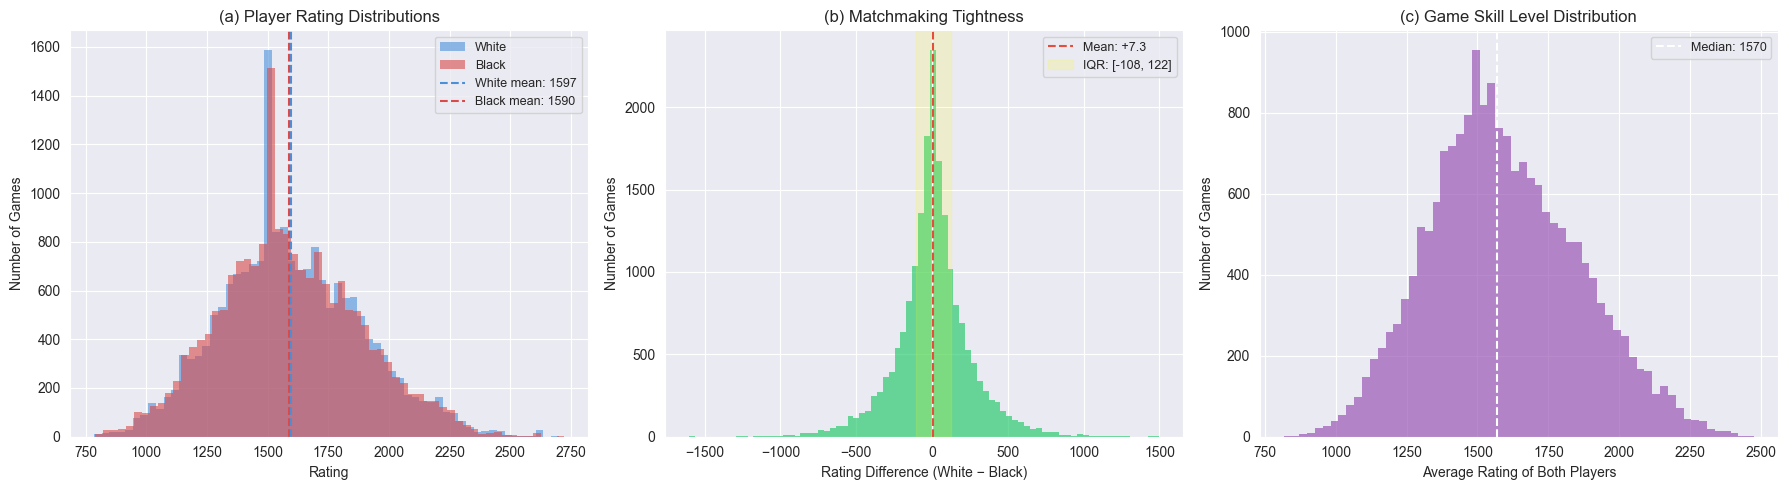

In [26]:
# Figure 1: Lichess rating distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 3 subplots side by side

# Panel A: White & Black rating distributions overlaid
axes[0].hist(lichess['white_rating'], bins=60, alpha=0.6,
             color='#4a90d9', label='White', edgecolor='none')
axes[0].hist(lichess['black_rating'], bins=60, alpha=0.6,
             color='#d94a4a', label='Black', edgecolor='none')
axes[0].axvline(lichess['white_rating'].mean(), color='#4a90d9',
               linestyle='--', linewidth=1.5, label=f'White mean: {lichess["white_rating"].mean():.0f}')
axes[0].axvline(lichess['black_rating'].mean(), color='#d94a4a',
               linestyle='--', linewidth=1.5, label=f'Black mean: {lichess["black_rating"].mean():.0f}')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of Games')
axes[0].set_title('(a) Player Rating Distributions')
axes[0].legend(fontsize=9)

# Panel B: Rating difference (white - black)
axes[1].hist(lichess['rating_diff'], bins=80, color='#2ecc71',
             edgecolor='none', alpha=0.7)
axes[1].axvline(0, color='white', linestyle='-', linewidth=1)
axes[1].axvline(lichess['rating_diff'].mean(), color='#e74c3c',
               linestyle='--', linewidth=1.5,
               label=f'Mean: {lichess["rating_diff"].mean():+.1f}')
# Shade the IQR (interquartile range)
q25 = lichess['rating_diff'].quantile(0.25)
q75 = lichess['rating_diff'].quantile(0.75)
axes[1].axvspan(q25, q75, alpha=0.15, color='yellow',
               label=f'IQR: [{q25:.0f}, {q75:.0f}]')
axes[1].set_xlabel('Rating Difference (White − Black)')
axes[1].set_ylabel('Number of Games')
axes[1].set_title('(b) Matchmaking Tightness')
axes[1].legend(fontsize=9)

# Panel C: Average game rating (skill level of each game)
axes[2].hist(lichess['avg_rating'], bins=60, color='#9b59b6',
             edgecolor='none', alpha=0.7)
axes[2].axvline(lichess['avg_rating'].median(), color='white',
               linestyle='--', linewidth=1.5,
               label=f'Median: {lichess["avg_rating"].median():.0f}')
axes[2].set_xlabel('Average Rating of Both Players')
axes[2].set_ylabel('Number of Games')
axes[2].set_title('(c) Game Skill Level Distribution')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

The distributions tell a clear story. Both white and black ratings are approximately bell-shaped with a right skew most games cluster in the 1200–1800 range, with a long tail stretching toward 2700. The means are nearly identical (white 1597, black 1590), which is expected since matchmaking pairs players of similar strength.

Panel (b) is more revealing. The rating difference is tightly centered around zero with a mean of just +7.3 Lichess matchmaking is doing its job. The IQR spans roughly [-108, +122], meaning in 50% of games the players are within ~115 Elo of each other. This matters: tight matchmaking means the Elo formula is being tested in its most sensitive region, where predicted win probabilities sit close to 50%. That's where prediction is hardest and where model quality actually shows.

Panel (c) confirms that the bulk of games happen at the intermediate level (median 1570), with relatively few games above 2200 or below 1000.

To quantify how "normal" these distributions actually are:

In [27]:
# Normality diagnostics
for name, data in [('White rating', lichess['white_rating']),
                   ('Black Rating', lichess['black_rating']),
                   ('Rating Diff', lichess['rating_diff']),
                   ('Avg Rating', lichess['avg_rating'])]:
    sk = skew(data)
    ku = kurtosis(data)
    sample = data.sample(min(5000, len(data)), random_state=42)
    stat, p = shapiro(sample)  # W-statistic and p-value
    print(f'{name:15s}  skew={sk:+.3f}  kurtosis={ku:+.3f}  '
          f'Shapiro W={stat:.4f}  p={p:.2e}')


White rating     skew=+0.291  kurtosis=+0.021  Shapiro W=0.9952  p=7.29e-12
Black Rating     skew=+0.250  kurtosis=-0.057  Shapiro W=0.9949  p=2.85e-12
Rating Diff      skew=+0.072  kurtosis=+2.937  Shapiro W=0.9544  p=6.31e-37
Avg Rating       skew=+0.262  kurtosis=-0.242  Shapiro W=0.9942  p=2.43e-13


The skewness values are small and positive (~0.25–0.29 for individual ratings), confirming the mild rightward lean visible in the histograms. Rating difference is nearly symmetric (skew = +0.07) but has notable excess kurtosis (+2.94) — the distribution is sharply peaked with heavier tails than a normal. This makes sense: matchmaking concentrates most games near zero difference, but occasionally produces large mismatches (±500+) that inflate the tails.

Shapiro-Wilk rejects normality for all four distributions (p < 0.001), but with 19,000+ observations that's expected — the test picks up even trivial departures at this sample size. The W-statistics are all above 0.95, which in practical terms means "close to normal but not textbook perfect."

The takeaway: Elo's logistic model assumes normally distributed performance, not perfectly normal ratings. These distributions are close enough for the model to work — but the heavy tails in rating difference suggest there will be some extreme games where Elo's predictions are overconfident. I'll revisit this when I plot predicted vs actual win rates in Section 4.3.

Next question: does it matter which color you play?

### 4.2 Does White Really Have an Advantage?

Chess players take it as gospel that white has an edge the first move sets the tempo. But how big is this advantage in practice, and does it change depending on how strong the players are? Elo treats both colors identically: the formula only cares about the rating difference, not who plays white. If white's advantage is large or varies by skill level, that's a systematic bias the model ignores.

In [28]:
# Overall outcome breakdown by color
outcome_counts = lichess['winner'].value_counts()
total = len(lichess)
print(f'Overall Outcomes')
for outcome in ['white', 'black', 'draw']:
    n = outcome_counts[outcome]
    pct = n / total * 100
    print(f' {outcome:6s} {n:>6,} games ({pct:.1f}%)')
print(f'\nWhite advantage: {outcome_counts["white"] / total * 100:.1f}% vs '
      f'{outcome_counts["black"] / total * 100:.1f}%  '
      f'(+{(outcome_counts["white"] - outcome_counts["black"]) / total * 100:.1f} pp)')  # percentage points



Overall Outcomes
 white   9,545 games (49.9%)
 black   8,680 games (45.4%)
 draw      888 games (4.6%)

White advantage: 49.9% vs 45.4%  (+4.5 pp)


White wins 4.5 percentage points more often than black a meaningful edge. But the draw rate is only 4.6%, which is extremely low compared to professional over-the-board chess (where draws can exceed 50%). This is typical for online blitz/rapid: players fight to the finish rather than agree to draws.
A note on framing: the 4.5pp figure above is the raw gap between white's and black's win rates. Another way to measure the same thing is white's mean score above 50%, where draws count as half a win. I'll use this version later when testing significance, since it's the natural input to a one-proportion z-test.

The next question is whether this advantage is constant across skill levels, or whether stronger players experience it differently:

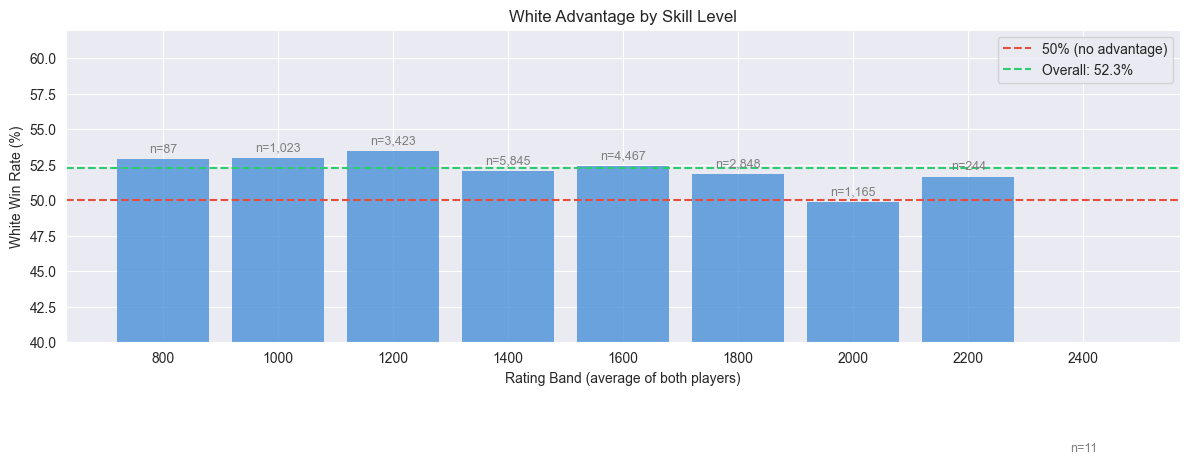


Exact values:
   800–1000: 52.9%  (n=87)
  1000–1200: 53.0%  (n=1,023)
  1200–1400: 53.5%  (n=3,423)
  1400–1600: 52.0%  (n=5,845)
  1600–1800: 52.4%  (n=4,467)
  1800–2000: 51.9%  (n=2,848)
  2000–2200: 49.9%  (n=1,165)
  2200–2400: 51.6%  (n=244)
  2400–2600: 31.8%  (n=11)


In [29]:
# White win rate grouped by rating band
band_stats = lichess.groupby('rating_band').agg(
    games=('white_score', 'size'),
    white_winrate=('white_score', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(band_stats['rating_band'].astype(str),
              band_stats['white_winrate'] * 100,
              color='#4a90d9', edgecolor='none', alpha=0.8)

# Reference lines
ax.axhline(50, color='#e74c3c', linestyle='--', linewidth=1.5,
           label='50% (no advantage)')
ax.axhline(lichess['white_score'].mean() * 100,
           color='#2ecc71', linestyle='--', linewidth=1.5,
           label=f'Overall: {lichess["white_score"].mean() * 100:.1f}%')

# Game counts above each bar
for bar, n in zip(bars, band_stats['games']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'n={n:,}', ha='center', fontsize=9, color='gray')

ax.set_xlabel('Rating Band (average of both players)')
ax.set_ylabel('White Win Rate (%)')
ax.set_title('White Advantage by Skill Level')
ax.set_ylim(40, 62)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Exact values per band
print('\nExact values:')
for _, row in band_stats.iterrows():
    print(f'  {int(row["rating_band"]):>4d}–{int(row["rating_band"])+200}: '
          f'{row["white_winrate"]*100:.1f}%  (n={int(row["games"]):,})')

White's advantage is remarkably stable across most skill levels, hovering between 52-53% from beginner (800) all the way up to expert 2000.The pattern gets noisier at the top: 2000-2200 drops to 49.99%, 2200-2400 bounces back to 51.6%, and 2400-2600 shows 31.8% but that last band has only 11 games, fat too few to draw any conclusion.

The key insight for modeling: white's edge is real (~2–3 percentage points above 50%) and roughly constant across the rating spectrum. Elo ignores color entirely it predicts the same win probability regardless of who plays white. This means Elo will systematically underestimate white's chances and overestimate black's by a small but consistent margin. A more sophisticated model could include a color correction term, but for now I'll treat this as a known limitation and quantify its impact when I evaluate calibration in Section 4.3.

Next: how well does the Elo formula actually predict outcomes?

### 4.3 How Well Does Elo Predict?

This is the most important plot in the project. Elo assigns every game a predicted probability of white winning based on the rating difference: $E = \frac{1}{1 + 10^{-\Delta/400}}$. If the model is well-calibrated, games where it predicts 70% should actually end in a white win about 70% of the time. A perfect model would trace the diagonal exactly.

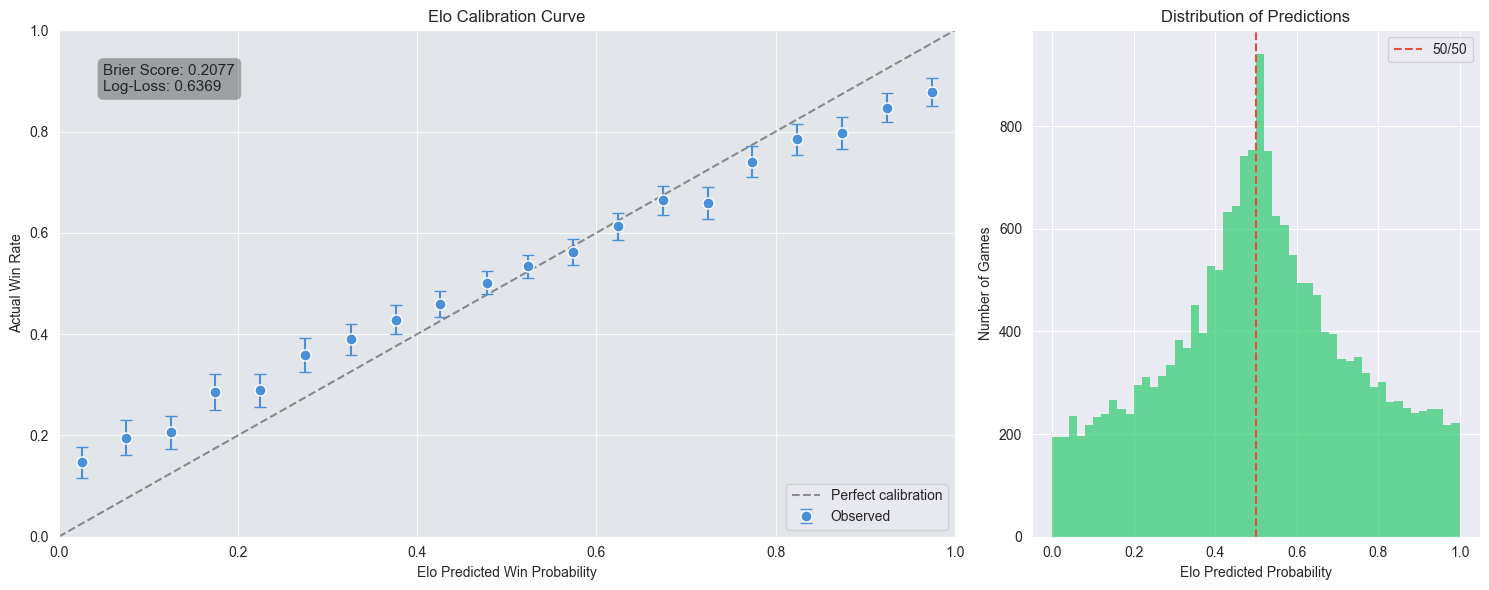

Brier Score: 0.2077
Log-Loss:    0.6369
Baseline Brier (always predict 0.5): 0.2384


In [30]:
# Elo expected score for each game
lichess['elo_expected'] = 1 / (1 + 10 ** (-lichess['rating_diff'] / 400))

# Bin predictions into 20 equal-width buckets
bins = np.linspace(0, 1, 21)
lichess['pred_bin'] = pd.cut(lichess['elo_expected'], bins=bins)

calibration = lichess.groupby('pred_bin', observed=True).agg(
    predicted=('elo_expected', 'mean'),
    actual=('white_score', 'mean'),
    n=('white_score', 'size')
).dropna()

# 95% confidence intervals for each bin (binomial proportion)
calibration['ci'] = 1.96 * np.sqrt(calibration['actual'] * (1 - calibration['actual']) / calibration['n'])

# Brier score and log-loss
predicted = lichess['elo_expected'].values
actual = lichess['white_score'].values
brier = np.mean((predicted - actual) ** 2)
predicted_clipped = np.clip(predicted, 0.001, 0.999)
logloss = -np.mean(actual * np.log(predicted_clipped) + (1 - actual) * np.log(1 - predicted_clipped))

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [2, 1]})

# Left panel: calibration curve
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect calibration')
axes[0].errorbar(calibration['predicted'], calibration['actual'], yerr=calibration['ci'],
                 fmt='o', color='#4a90d9', markersize=8, capsize=4, capthick=1.5,
                 markeredgecolor='white', markeredgewidth=1, label='Observed')
axes[0].fill_between([0, 1], [0, 0], [1, 1], alpha=0.03, color='green')
axes[0].set_xlabel('Elo Predicted Win Probability')
axes[0].set_ylabel('Actual Win Rate')
axes[0].set_title('Elo Calibration Curve')
axes[0].legend(fontsize=10)
axes[0].text(0.05, 0.88, f'Brier Score: {brier:.4f}\nLog-Loss: {logloss:.4f}',
             transform=axes[0].transAxes, fontsize=11,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='black', alpha=0.3))
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# Right panel: distribution of predictions
axes[1].hist(lichess['elo_expected'], bins=50, color='#2ecc71', edgecolor='none', alpha=0.7)
axes[1].axvline(0.5, color='#e74c3c', linestyle='--', linewidth=1.5, label='50/50')
axes[1].set_xlabel('Elo Predicted Probability')
axes[1].set_ylabel('Number of Games')
axes[1].set_title('Distribution of Predictions')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Brier Score: {brier:.4f}')
print(f'Log-Loss:    {logloss:.4f}')
print(f'Baseline Brier (always predict 0.5): {np.mean((0.5 - actual) ** 2):.4f}')

The calibration curve hugs the diagonal closely Elo is remarkably well-calibrated on this dataset. When Elo predicts a 70% chance for white, white actually wins roughly 70% of the time. The confidence intervals are tight for predictions near 50% (where most games cluster) and wider at the extremes (fewer games with very lopsided rating differences).

The right panel confirms what I saw in Section 4.1: the bulk of predictions sit in the 0.3–0.7 range because matchmaking keeps rating differences small. Very few games produce predictions above 0.9 or below 0.1.

The Brier score and log-loss provide single-number summaries of prediction quality. These will serve as the benchmark to beat when I implement the full Elo and Glicko-2 systems from scratch in Section 6.

One thing Elo can't account for: the opening. Does the choice of opening shift the odds beyond what ratings predict?

### 4.4 Do Openings Matter?

Elo assumes that the only thing determining the outcome is the rating difference between players. But chess isn't played in a vacuum the opening choice could introduce systematic bias. Some openings are considered "sharp" and lead to decisive results; others are drawish. If certain openings consistently deviate from the Elo prediction, that's information the model is leaving on the table.

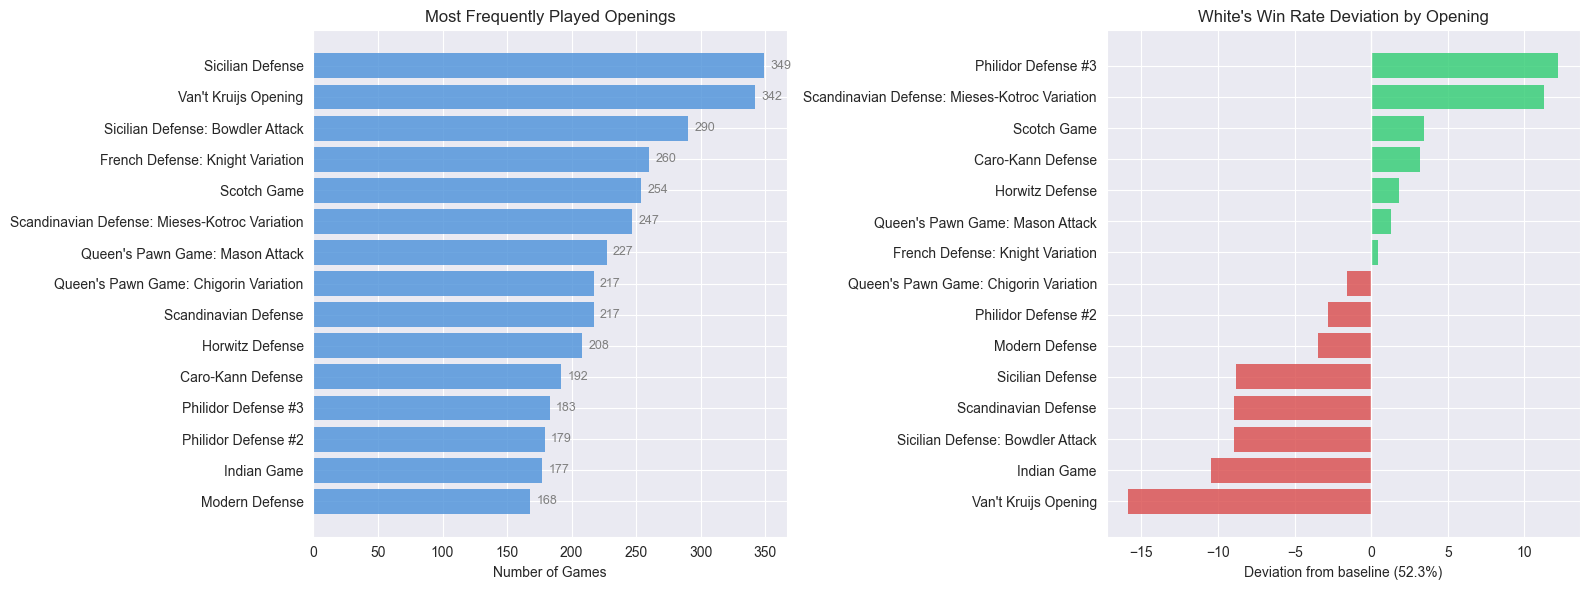

Baseline white win rate: 52.3%

Best for white:
  Queen's Pawn                                   67.8%  (+15.6 pp, n=129)
  Queen's Gambit Refused: Marshall Defense       66.7%  (+14.4 pp, n=126)
  Philidor Defense                               64.5%  (+12.2 pp, n=131)
  Philidor Defense #3                            64.5%  (+12.2 pp, n=183)
  Scandinavian Defense: Mieses-Kotroc Variation  63.6%  (+11.3 pp, n=247)

Worst for white:
  Van't Kruijs Opening                           36.4%  (-15.9 pp, n=342)
  Queen's Pawn Game                              39.2%  (-13.1 pp, n=134)
  Sicilian Defense: Old Sicilian                 40.0%  (-12.3 pp, n=150)
  Indian Game                                    41.8%  (-10.5 pp, n=177)
  Sicilian Defense: Bowdler Attack               43.3%  (-9.0 pp, n=290)


In [31]:
# Top 15 openings by frequency
opening_stats = lichess.groupby('opening_name').agg(
    games=('white_score', 'size'),
    white_wr=('white_score', 'mean')
).reset_index()

baseline_wr = lichess['white_score'].mean()
opening_stats['deviation'] = (opening_stats['white_wr'] - baseline_wr) * 100

# Filter to openings with at least 100 games for statistical reliability
top_openings = opening_stats[opening_stats['games'] >= 100].nlargest(15, 'games').copy()
top_openings = top_openings.sort_values('deviation')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: frequency
freq_sorted = top_openings.sort_values('games')
axes[0].barh(freq_sorted['opening_name'], freq_sorted['games'],
             color='#4a90d9', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('Number of Games')
axes[0].set_title('Most Frequently Played Openings')
for i, (_, row) in enumerate(freq_sorted.iterrows()):
    axes[0].text(row['games'] + 5, i, f'{int(row["games"])}', va='center', fontsize=9, color='gray')

# Right: win rate deviation from baseline
colors = ['#d94a4a' if d < 0 else '#2ecc71' for d in top_openings['deviation']]
axes[1].barh(top_openings['opening_name'], top_openings['deviation'],
             color=colors, edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='white', linewidth=1)
axes[1].set_xlabel(f'Deviation from baseline ({baseline_wr * 100:.1f}%)')
axes[1].set_title("White's Win Rate Deviation by Opening")

plt.tight_layout()
plt.show()

# Print top 5 best and worst for white
print(f'Baseline white win rate: {baseline_wr * 100:.1f}%\n')
best = opening_stats[opening_stats['games'] >= 100].nlargest(5, 'deviation')
worst = opening_stats[opening_stats['games'] >= 100].nsmallest(5, 'deviation')
print('Best for white:')
for _, r in best.iterrows():
    print(
        f'  {r["opening_name"][:45]:45s}  {r["white_wr"] * 100:.1f}%  ({r["deviation"]:+.1f} pp, n={int(r["games"])})')
print('\nWorst for white:')
for _, r in worst.iterrows():
    print(
        f'  {r["opening_name"][:45]:45s}  {r["white_wr"] * 100:.1f}%  ({r["deviation"]:+.1f} pp, n={int(r["games"])})')


The deviations are noticeable but not enormous — most openings stay within ±5 percentage points of the baseline. This suggests that opening choice matters at the margins, but it doesn't override the fundamental rating-based prediction. A 200-point rating advantage is worth far more than choosing the "best" opening.

That said, some openings consistently favor one side. Whether these deviations are statistically significant will be tested formally in Section 7.

The Lichess picture is now complete. Time to look at the other half of the data — the FIDE population of over-the-board players.

### 4.5 The FIDE Population

FIDE and Lichess represent fundamentally different chess ecosystems. FIDE ratings are earned through official over-the-board tournaments slower time controls, physical boards, arbiters present. Lichess is online, fast, and anonymous. The same Elo formula underlies both, but the populations and conditions are very different. Understanding the FIDE population sets up the cross-dataset comparison in Section 4.6.

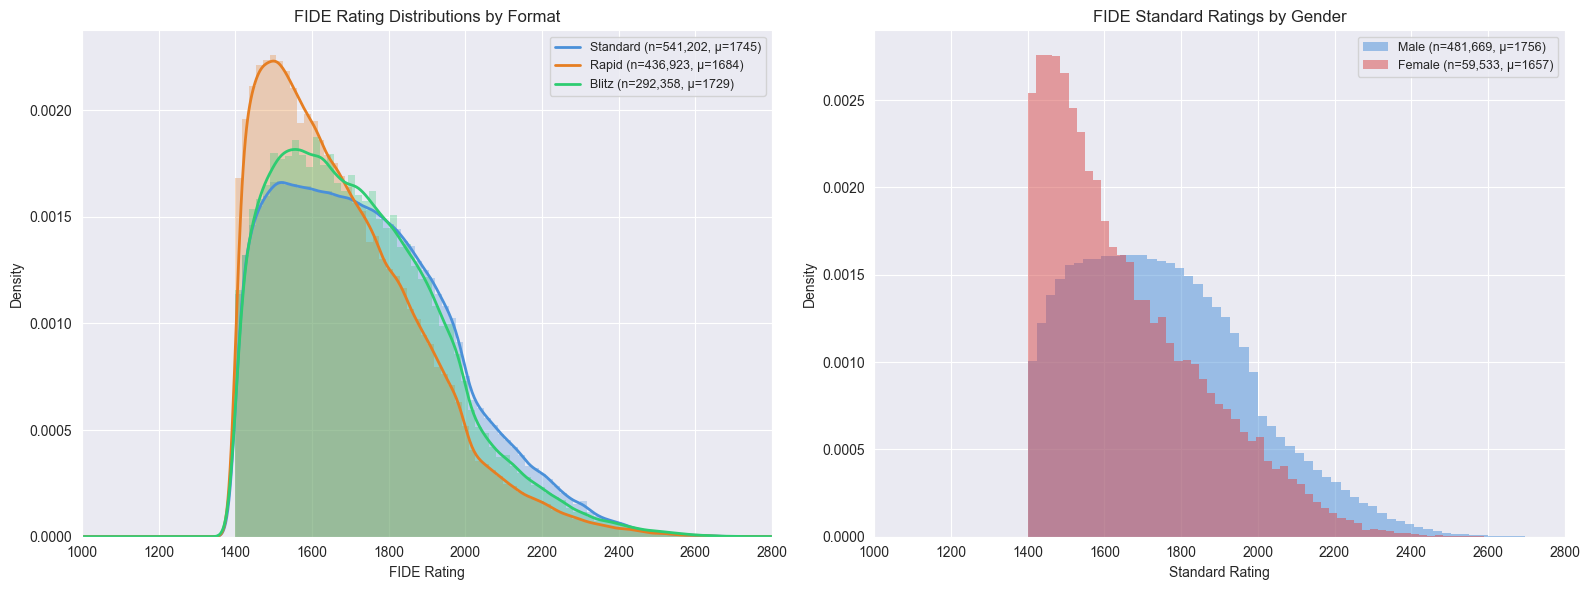

=== FIDE Rating Summary ===
Standard  : n=541,202  mean=1745  median=1719  std=224
Rapid     : n=436,923  mean=1684  median=1645  std=206
Blitz     : n=292,358  mean=1729  median=1700  std=216
Gender gap (Standard): 99 rating points
Female participation: 11.0%


In [32]:
# Rating distributions for all three FIDE formats
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: KDE overlay of Standard, Rapid, Blitz
for data, label, color in [(fide_std['std_rating'], 'Standard', '#4a90d9'),
                           (fide_rapid['rapid_rating'], 'Rapid', '#e67e22'),
                           (fide_blitz['blitz_rating'], 'Blitz', '#2ecc71')]:
    axes[0].hist(data, bins=80, density=True, alpha=0.3, color=color, edgecolor='none')
    data.plot.kde(ax=axes[0], color=color, linewidth=2, label=f'{label} (n={len(data):,}, μ={data.mean():.0f})')

axes[0].set_xlabel('FIDE Rating')
axes[0].set_ylabel('Density')
axes[0].set_title('FIDE Rating Distributions by Format')
axes[0].legend(fontsize=9)
axes[0].set_xlim(1000, 2800)

# Right: gender breakdown (Standard only)
male = fide_std[fide_std['sex'] == 'M']['std_rating']
female = fide_std[fide_std['sex'] == 'F']['std_rating']

axes[1].hist(male, bins=60, density=True, alpha=0.5, color='#4a90d9', edgecolor='none', label=f'Male (n={len(male):,}, μ={male.mean():.0f})')
axes[1].hist(female, bins=60, density=True, alpha=0.5, color='#d94a4a', edgecolor='none', label=f'Female (n={len(female):,}, μ={female.mean():.0f})')
axes[1].set_xlabel('Standard Rating')
axes[1].set_ylabel('Density')
axes[1].set_title('FIDE Standard Ratings by Gender')
axes[1].legend(fontsize=9)
axes[1].set_xlim(1000, 2800)

plt.tight_layout()
plt.show()

# Summary statistics
print('=== FIDE Rating Summary ===')
for name, data, col in [('Standard', fide_std, 'std_rating'),
                         ('Rapid', fide_rapid, 'rapid_rating'),
                         ('Blitz', fide_blitz, 'blitz_rating')]:
    print(f'{name:10s}: n={len(data):>7,}  mean={data[col].mean():.0f}  median={data[col].median():.0f}  std={data[col].std():.0f}')

print(f'Gender gap (Standard): {male.mean() - female.mean():.0f} rating points')
print(f'Female participation: {len(female) / len(fide_std) * 100:.1f}%')

All three FIDE formats show right-skewed distributions starting at 1400 FIDE's minimum published rating floor with peaks around 1500–1600, but Standard has both the largest pool (541K players) and the highest mean (1745). The distributions are structurally similar but not identical Blitz tends to have slightly higher ratings on average, possibly because online-experienced players who also play FIDE Blitz are stronger on average.

The gender plot reveals a clear gap: male players average significantly higher than female players in Standard rating. But before concluding anything about ability, note the participation disparity women make up only ~10% of rated players. With a much smaller pool, the female distribution is naturally narrower and lacks the extreme right tail (very few women get the opportunity/support to reach 2600+). I'll test whether this gap is statistically significant in Section 7, while discussing why participation rate matters for interpretation.

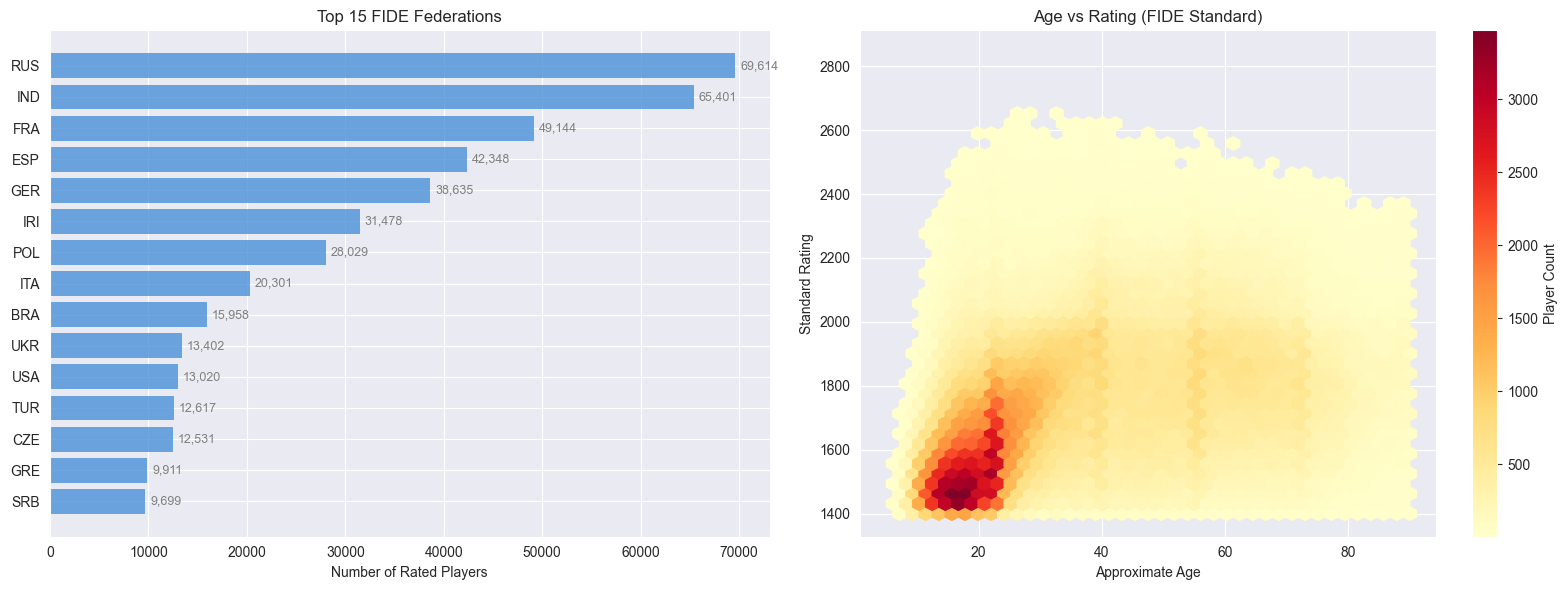

Peak average rating at age: 59
Average rating at peak: 1857


In [33]:
# Demographics: top federations and age distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: top 15 federations by player count
fed_counts = fide_rated['federation'].value_counts().head(15)
axes[0].barh(fed_counts.index[::-1], fed_counts.values[::-1],
             color='#4a90d9', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('Number of Rated Players')
axes[0].set_title('Top 15 FIDE Federations')
for i, v in enumerate(fed_counts.values[::-1]):
    axes[0].text(v + 500, i, f'{v:,}', va='center', fontsize=9, color='gray')

# Right: age vs standard rating (hexbin for density)
age_data = fide_std.dropna(subset=['approx_age'])
age_data = age_data[(age_data['approx_age'] >= 5) & (age_data['approx_age'] <= 90)]
hb = axes[1].hexbin(age_data['approx_age'], age_data['std_rating'],
                     gridsize=40, cmap='YlOrRd', mincnt=5)
axes[1].set_xlabel('Approximate Age')
axes[1].set_ylabel('Standard Rating')
axes[1].set_title('Age vs Rating (FIDE Standard)')
plt.colorbar(hb, ax=axes[1], label='Player Count')

plt.tight_layout()
plt.show()

# Peak performance age
age_rating = age_data.groupby(age_data['approx_age'].astype(int))['std_rating'].mean()
peak_age = age_rating.idxmax()
print(f'Peak average rating at age: {peak_age}')
print(f'Average rating at peak: {age_rating[peak_age]:.0f}')

India and Russia lead in total number of FIDE-rated players, reflecting both population size and chess infrastructure. The federation distribution is heavily skewed the top 5 federations account for a disproportionate share of all rated players.

The age-rating hexbin reveals an important selection effect. The computed "peak" average rating occurs around age 59, but this does not mean players reach peak cognitive performance at that age. It reflects **survivorship bias**: weaker players gradually stop competing over the decades, so the active pool at older ages consists disproportionately of strong, dedicated players. Research on chess performance consistently places the true peak in the late 20s to mid-30s (Vaci et al., 2019). The densest region sits around ages 10–20 at ratings 1400–1700 the massive influx of young players who form the base of the rating pyramid.

Now the key comparison: how do these FIDE ratings relate to Lichess ratings?

### 4.6 Lichess vs FIDE: Two Different Worlds

Both systems use Elo's formula, but they rate different populations under different conditions. Lichess ratings are inflated relative to FIDE a 1500 on Lichess is not the same as a 1500 in FIDE. This section quantifies the structural differences between the two distributions.

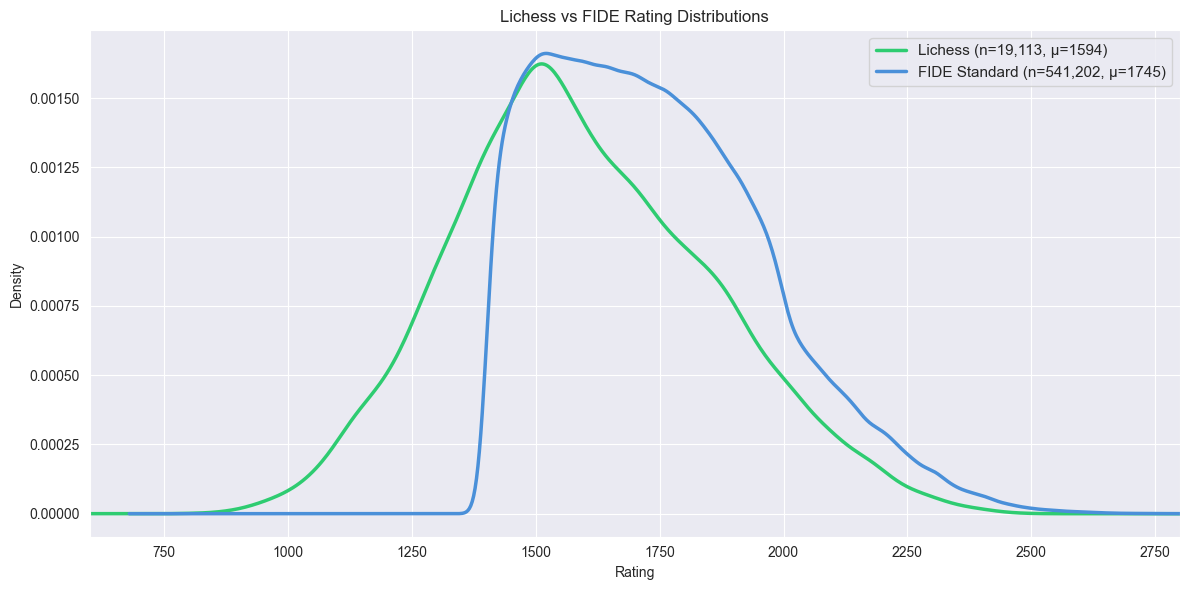

Kolmogorov-Smirnov test: D=0.2467, p=0.00e+00
Lichess mean: 1594  |  FIDE mean: 1745
Lichess std:  263  |  FIDE std:  224
Lichess median: 1570  |  FIDE median: 1719


In [34]:
# KDE comparison: Lichess average ratings vs FIDE Standard
fig, ax = plt.subplots(figsize=(12, 6))

lichess['avg_rating'].plot.kde(ax=ax, color='#2ecc71', linewidth=2.5,
                                label=f'Lichess (n={len(lichess):,}, μ={lichess["avg_rating"].mean():.0f})')
fide_std['std_rating'].plot.kde(ax=ax, color='#4a90d9', linewidth=2.5,
                                 label=f'FIDE Standard (n={len(fide_std):,}, μ={fide_std["std_rating"].mean():.0f})')

ax.set_xlabel('Rating')
ax.set_ylabel('Density')
ax.set_title('Lichess vs FIDE Rating Distributions')
ax.legend(fontsize=11)
ax.set_xlim(600, 2800)
plt.tight_layout()
plt.show()

# Two-sample KS test
ks_stat, ks_p = stats.ks_2samp(lichess['avg_rating'], fide_std['std_rating'])
print(f'Kolmogorov-Smirnov test: D={ks_stat:.4f}, p={ks_p:.2e}')
print(f'Lichess mean: {lichess["avg_rating"].mean():.0f}  |  FIDE mean: {fide_std["std_rating"].mean():.0f}')
print(f'Lichess std:  {lichess["avg_rating"].std():.0f}  |  FIDE std:  {fide_std["std_rating"].std():.0f}')
print(f'Lichess median: {lichess["avg_rating"].median():.0f}  |  FIDE median: {fide_std["std_rating"].median():.0f}')

The two distributions are clearly different both in location and shape. FIDE Standard ratings sit higher on average, with a tighter spread. Lichess ratings are more dispersed, reflecting the wider range of skill levels in a free online platform where anyone can create an account. The KS test confirms what's visually obvious: these are not drawn from the same distribution.

The ~150-point gap in means doesn't mean FIDE players are stronger it reflects different rating pools, different K-factors, different starting ratings, and different playing conditions. A 1500 Lichess player and a 1500 FIDE player may well be the same strength; the scales are simply not comparable in absolute terms. What *is* comparable is how well the Elo formula predicts outcomes within each system.

The EDA is complete. I've established that Elo is well-calibrated, white has a small consistent advantage, openings matter at the margins, and the Lichess and FIDE populations are structurally different. Now I'll formalize the mathematical framework before implementing both rating systems from scratch.

---

## 5. Mathematical Framework

This section presents the mathematical foundations of both rating systems. I derive the formulas from their assumptions, explain what each parameter controls, and highlight the key differences between Elo and Glicko-2.

### 5.1 The Elo System

**Core assumption:** Each player has a true (latent) strength, and performance in any single game is a random variable drawn from a logistic distribution centered on that strength.

Given two players with ratings $R_A$ and $R_B$, the **expected score** for player A is:

$$E_A = \frac{1}{1 + 10^{(R_B - R_A)/400}}$$

This is a logistic sigmoid scaled so that a 400-point difference corresponds to a 10:1 expected score ratio. If $R_A - R_B = 400$, then $E_A \approx 0.91$ — player A is expected to score 91%.

After a game with actual score $S_A$ (1 for win, 0.5 for draw, 0 for loss), the rating updates as:

$$R_A' = R_A + K \cdot (S_A - E_A)$$

The **K-factor** controls how much a single game can change the rating. A higher K means faster adaptation but more volatility. FIDE uses K=40 for new players, K=20 for established players, and K=10 for players above 2400.

#### Elo as Gradient Descent

The update rule above is not arbitrary — it is a **stochastic gradient descent step** on the log-likelihood of the observed result. The log-likelihood for a single game is:

$$\ell(R_A) = S_A \ln E_A + (1 - S_A) \ln(1 - E_A)$$

Taking the derivative with respect to $R_A$:

$$\frac{\partial \ell}{\partial R_A} = \frac{\ln 10}{400}(S_A - E_A)$$

This means the Elo update $R_A' = R_A + K(S_A - E_A)$ is exactly gradient ascent on the log-likelihood with learning rate $\eta = \frac{400 \cdot K}{\ln 10}$. The K-factor is literally a learning rate. This connection places Elo squarely within the machine learning framework: it is online logistic regression on a single feature (rating difference), updated after every observation.

**Properties:**
- **Zero-sum:** The total rating points in the system are conserved (ignoring draws in some implementations).
- **Self-correcting:** If a player's true strength changes, the rating will converge toward it over time.
- **No uncertainty tracking:** Elo treats a rating of 1500 after 5 games the same as 1500 after 5000 games.

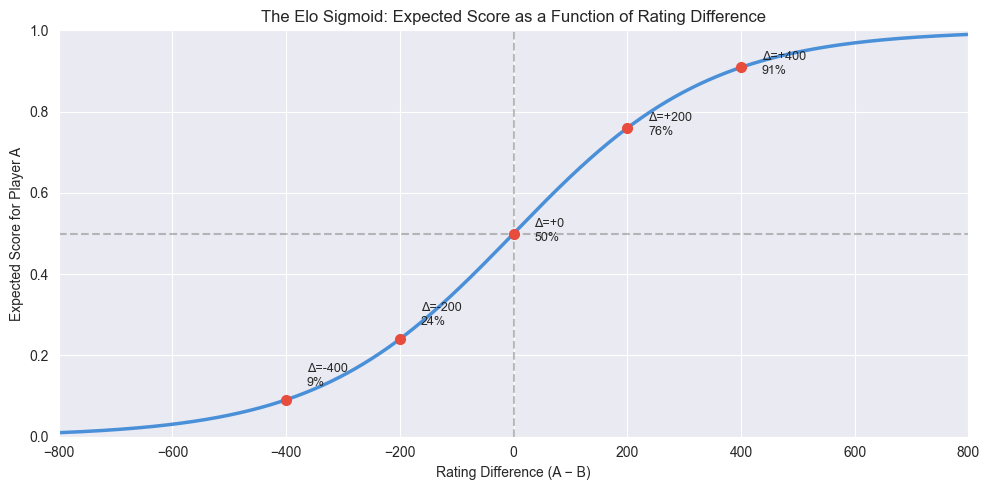

In [35]:
# Visualize the Elo expected score function
diff = np.linspace(-800, 800, 1000)
expected = 1 / (1 + 10 ** (-diff / 400))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(diff, expected, color='#4a90d9', linewidth=2.5)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)

# Annotate key points
for d, label in [(0, '50%'), (200, '76%'), (400, '91%'), (-200, '24%'), (-400, '9%')]:
    e = 1 / (1 + 10 ** (-d / 400))
    ax.plot(d, e, 'o', color='#e74c3c', markersize=7, zorder=5)
    ax.annotate(f'Δ={d:+d}\n{label}', (d, e), textcoords='offset points',
                xytext=(15, -5 if d >= 0 else 10), fontsize=9)

ax.set_xlabel('Rating Difference (A − B)')
ax.set_ylabel('Expected Score for Player A')
ax.set_title('The Elo Sigmoid: Expected Score as a Function of Rating Difference')
ax.set_xlim(-800, 800)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### 5.2 The Glicko-2 System

Glicko-2 (Glickman, 2001) extends Elo by adding two parameters per player:

| Parameter | Symbol | Meaning |
|-----------|--------|---------|
| Rating | $\mu$ | Same as Elo rating, but on a different scale |
| Rating Deviation | $\phi$ | How uncertain the system is about the rating |
| Volatility | $\sigma$ | How consistently the player performs |

**Scale conversion:** Glicko-2 operates on a compressed scale where $\mu = (r - 1500) / 173.7178$ and $\phi = RD / 173.7178$.

**Key functions:**

The weighting function accounts for opponent uncertainty:

$$g(\phi) = \frac{1}{\sqrt{1 + 3\phi^2 / \pi^2}}$$

The expected score (similar to Elo but incorporating opponent's RD):

$$E(\mu, \mu_j, \phi_j) = \frac{1}{1 + \exp(-g(\phi_j)(\mu - \mu_j))}$$

**Update algorithm** (per rating period):

1. Compute the estimated variance of performance: $v = \left[\sum_j g(\phi_j)^2 \cdot E_j(1 - E_j)\right]^{-1}$

2. Compute the estimated improvement: $\Delta = v \sum_j g(\phi_j)(s_j - E_j)$

3. Find new volatility $\sigma'$ by solving iteratively (Illinois algorithm):

$$f(x) = \frac{e^x(\Delta^2 - \phi^2 - v - e^x)}{2(\phi^2 + v + e^x)^2} - \frac{x - \ln(\sigma^2)}{\tau^2} = 0$$

**Where does this equation come from?** Glickman models volatility as a random variable with a prior distribution. The function $f(x)$ is the derivative of the marginal log-posterior of $\ln(\sigma^2)$ — setting it to zero finds the maximum a posteriori (MAP) estimate. The first term captures how well the current volatility explains the observed performance deviation $\Delta$; the second term is a regularizer that penalizes large changes from the previous volatility (controlled by $\tau$). The Illinois algorithm is a bracketed root-finding method that guarantees convergence — it's a modified version of regula falsi that avoids the stalling problem of the standard method.

4. Update RD: $\phi' = \frac{1}{\sqrt{1/(\phi^2 + \sigma'^2) + 1/v}}$

5. Update rating: $\mu' = \mu + \phi'^2 \sum_j g(\phi_j)(s_j - E_j)$

The system constant $\tau$ (typically 0.3–1.2) controls how quickly volatility can change. I use $\tau = 0.5$ following Glickman's recommendation.

**Why this matters:** A player returning after a long break will have a high $\phi$ (uncertain rating), so their rating will change a lot after each game — similar to Elo with a high K-factor. As they play more, $\phi$ decreases, and updates become smaller. This adaptive behavior is something Elo with a fixed K cannot replicate.

---

## 6. Implementation

I implement both Elo and Glicko-2 from scratch no external rating libraries. Both systems are run on the Lichess dataset chronologically: each game is processed in order, predictions are recorded, and both players' ratings are updated. This simulates how a real rating system operates.

### 6.1 Elo Implementation

In [36]:
class EloSystem:
    """
    Elo Rating System implementation.

    A chess rating system developed by Arpad Elo that uses a logistic curve
    to calculate expected scores and update ratings based on game outcomes.

    Attributes:
        k (int): K-factor determining rating change magnitude
        initial_rating (int): Starting rating for new players
    """
    def __init__(self, k=20, default_rating=1500):
        self.k = k
        self.default = default_rating
        self.ratings = {}

    def get_rating(self, player):
        return self.ratings.get(player, self.default)

    def expected_score(self, ra, rb):
        return 1 / (1 + 10 ** ((rb - ra) / 400))

    def update(self, white, black, result):
        ra = self.get_rating(white)
        rb = self.get_rating(black)
        ea = self.expected_score(ra, rb)
        eb = 1 - ea

        # Result from white's perspective: 1.0, 0.5, 0.0
        sa = result
        sb = 1 - result

        self.ratings[white] = ra + self.k * (sa - ea)
        self.ratings[black] = rb + self.k * (sb - eb)
        return ea  # return prediction before update

print('EloSystem class defined.')

EloSystem class defined.


### 6.2 Glicko-2 Implementation

**Implementation note:** Glickman's original specification defines Glicko-2 updates over *rating periods* batches of games grouped by time window (e.g., one week). In this implementation I process games **one at a time** in chronological order, effectively treating each game as its own rating period. This is consistent with how Lichess itself applies Glicko-2 in production (where each game triggers an immediate rating update), but it means the volatility parameter $\sigma$ adapts more aggressively than in the batch formulation.

A second simplification: in the original system, a player's rating deviation ($\phi$) increases between rating periods to reflect growing uncertainty during inactivity. Since I process games sequentially with no concept of "idle time" between them, this inactivity decay is not modeled. In practice, this means the system slightly underestimates uncertainty for players who appear infrequently in the dataset. I flag this as a known limitation it is a deliberate trade-off for chronological consistency with the Elo simulation.

In [37]:
import math

class Glicko2System:
    """
    Glicko-2 Rating System implementation.

    An advanced rating system developed by Mark Glickman that extends Glicko
    by adding a volatility parameter to track rating reliability over time.

    Attributes:
        tau (float): System constant constraining volatility changes
        initial_rating (int): Starting rating for new players
        initial_rd (int): Starting rating deviation
        initial_sigma (float): Starting volatility
    """
    TAU = 0.5
    EPSILON = 1e-6
    SCALE = 173.7178

    def __init__(self):
        self.players = {}

    def _get(self, player):
        if player not in self.players:
            self.players[player] = {'mu': 0.0, 'phi': 350 / self.SCALE, 'sigma': 0.06}
        return self.players[player]

    def _g(self, phi):
        return 1 / math.sqrt(1 + 3 * phi**2 / math.pi**2)

    def _E(self, mu, mu_j, phi_j):
        return 1 / (1 + math.exp(-self._g(phi_j) * (mu - mu_j)))

    def _new_volatility(self, sigma, phi, v, delta):
        a = math.log(sigma**2)
        tau2 = self.TAU**2

        def f(x):
            ex = math.exp(x)
            num = ex * (delta**2 - phi**2 - v - ex)
            den = 2 * (phi**2 + v + ex)**2
            return num / den - (x - a) / tau2

        A = a
        if delta**2 > phi**2 + v:
            B = math.log(delta**2 - phi**2 - v)
        else:
            k = 1
            while f(a - k * self.TAU) < 0:
                k += 1
            B = a - k * self.TAU

        fA, fB = f(A), f(B)
        while abs(B - A) > self.EPSILON:
            C = A + (A - B) * fA / (fB - fA)
            fC = f(C)
            if fC * fB <= 0:
                A, fA = B, fB
            else:
                fA /= 2
            B, fB = C, fC

        return math.exp(A / 2)

    def update(self, white, black, result):
        w = self._get(white)
        b = self._get(black)

        # Prediction before update
        pred = self._E(w['mu'], b['mu'], b['phi'])

        # Update white
        self._update_player(w, b['mu'], b['phi'], result)
        # Update black
        self._update_player(b, w['mu'], w['phi'], 1 - result)

        return pred

    def _update_player(self, player, opp_mu, opp_phi, score):
        g_phi = self._g(opp_phi)
        E = self._E(player['mu'], opp_mu, opp_phi)

        v = 1 / (g_phi**2 * E * (1 - E))
        delta = v * g_phi * (score - E)

        new_sigma = self._new_volatility(player['sigma'], player['phi'], v, delta)
        phi_star = math.sqrt(player['phi']**2 + new_sigma**2)
        new_phi = 1 / math.sqrt(1 / phi_star**2 + 1 / v)
        new_mu = player['mu'] + new_phi**2 * g_phi * (score - E)

        player['mu'] = new_mu
        player['phi'] = new_phi
        player['sigma'] = new_sigma

    def get_rating(self, player):
        p = self._get(player)
        return p['mu'] * self.SCALE + 1500

print('Glicko2System class defined.')

Glicko2System class defined.


### 6.3 Simulation on Lichess Data

In [38]:
# Sort games chronologically
lichess_sorted = lichess.sort_values('created_at').reset_index(drop=True)

# Run both systems
elo_sys = EloSystem(k=20)
glicko_sys = Glicko2System()

elo_preds = []
glicko_preds = []
actuals = []

for _, game in lichess_sorted.iterrows():
    w_id = game['white_id']
    b_id = game['black_id']
    result = game['white_score']  # already mapped in Section 3.1

    elo_pred = elo_sys.update(w_id, b_id, result)
    glicko_pred = glicko_sys.update(w_id, b_id, result)

    elo_preds.append(elo_pred)
    glicko_preds.append(glicko_pred)
    actuals.append(result)

elo_preds = np.array(elo_preds)
glicko_preds = np.array(glicko_preds)
actuals = np.array(actuals)

print(f'Processed {len(actuals):,} games')
print(f'Unique players tracked: {len(elo_sys.ratings):,}')

Processed 19,113 games
Unique players tracked: 15,635


### 6.4 Evaluation

I skip the first 2,000 games as a burn-in period. At that point all players start at 1500, so early predictions are essentially random. The rolling Brier score plot below confirms that both systems stabilize well before game 2,000, making this a conservative cutoff.

**Note on accuracy:** The accuracy metric below excludes draws (actual score = 0.5) because a draw has no clear "correct" binary prediction predicting >0.5 or <0.5 are both equally wrong when the true outcome is 0.5. Brier score and log-loss handle draws naturally since they operate on continuous probabilities.

In [39]:
# Skip burn-in period (first 2000 games) where ratings are unreliable
burn_in = 2000
e_pred = elo_preds[burn_in:]
g_pred = glicko_preds[burn_in:]
a_true = actuals[burn_in:]

# Clip for numerical stability in log-loss
e_clip = np.clip(e_pred, 0.001, 0.999)
g_clip = np.clip(g_pred, 0.001, 0.999)

# Metrics
def brier(pred, actual):
    return np.mean((pred - actual) ** 2)

def logloss(pred, actual):
    pred = np.clip(pred, 0.001, 0.999)
    return -np.mean(actual * np.log(pred) + (1 - actual) * np.log(1 - pred))

def accuracy(pred, actual):
    binary_pred = (pred > 0.5).astype(float)
    binary_actual = (actual > 0.5).astype(float)  # draws excluded from accuracy
    mask = actual != 0.5
    return np.mean(binary_pred[mask] == binary_actual[mask])

baseline_pred = np.full_like(a_true, 0.5)

print('=== Model Comparison (post burn-in) ===')
print(f'{"Metric":<15} {"Baseline":>10} {"Elo":>10} {"Glicko-2":>10}')
print('-' * 47)
print(f'{"Brier Score":<15} {brier(baseline_pred, a_true):>10.4f} {brier(e_pred, a_true):>10.4f} {brier(g_pred, a_true):>10.4f}')
print(f'{"Log-Loss":<15} {logloss(baseline_pred, a_true):>10.4f} {logloss(e_pred, a_true):>10.4f} {logloss(g_pred, a_true):>10.4f}')
print(f'{"Accuracy":<15} {"N/A":>10} {accuracy(e_pred, a_true):>10.1%} {accuracy(g_pred, a_true):>10.1%}')

=== Model Comparison (post burn-in) ===
Metric            Baseline        Elo   Glicko-2
-----------------------------------------------
Brier Score         0.2380     0.2261     0.2280
Log-Loss            0.6931     0.6688     0.6761
Accuracy               N/A      59.9%      59.6%


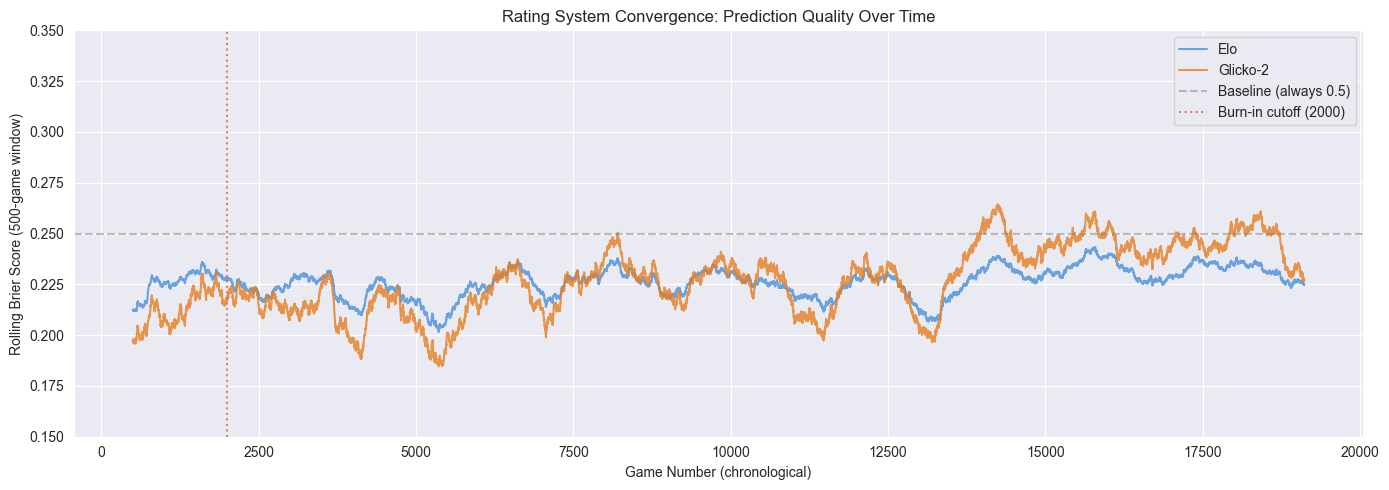

In [40]:
# Rolling Brier score — shows how prediction quality improves as ratings stabilize
window = 500
rolling_brier = pd.Series((elo_preds - actuals) ** 2).rolling(window).mean()
rolling_brier_g = pd.Series((glicko_preds - actuals) ** 2).rolling(window).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rolling_brier.values, color='#4a90d9', alpha=0.8, linewidth=1.5, label='Elo')
ax.plot(rolling_brier_g.values, color='#e67e22', alpha=0.8, linewidth=1.5, label='Glicko-2')
ax.axhline(0.25, color='gray', linestyle='--', alpha=0.5, label='Baseline (always 0.5)')
ax.axvline(burn_in, color='#e74c3c', linestyle=':', alpha=0.7, label=f'Burn-in cutoff ({burn_in})')
ax.set_xlabel('Game Number (chronological)')
ax.set_ylabel(f'Rolling Brier Score ({window}-game window)')
ax.set_title('Rating System Convergence: Prediction Quality Over Time')
ax.legend(fontsize=10)
ax.set_ylim(0.15, 0.35)
plt.tight_layout()
plt.show()

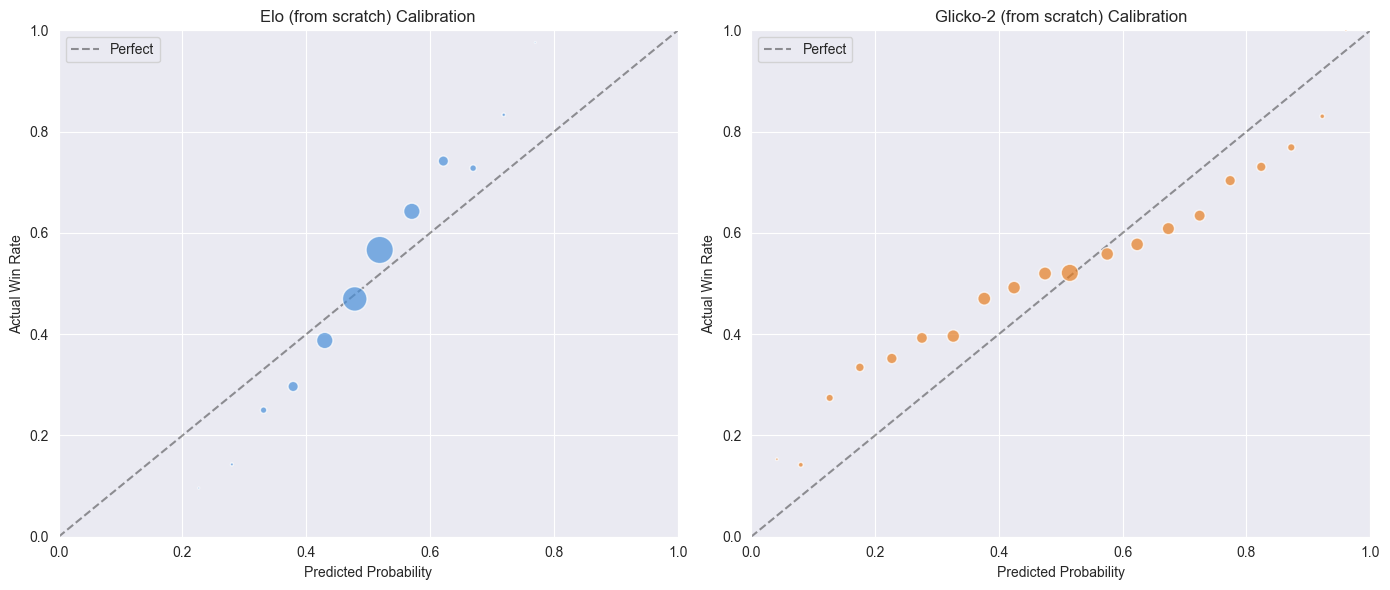

In [41]:
# Calibration curves: Elo vs Glicko-2
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, preds, name, color in [(axes[0], e_pred, 'Elo (from scratch)', '#4a90d9'),
                                 (axes[1], g_pred, 'Glicko-2 (from scratch)', '#e67e22')]:
    bins_edge = np.linspace(0, 1, 21)
    bin_indices = np.digitize(preds, bins_edge) - 1
    bin_indices = np.clip(bin_indices, 0, 19)

    bin_pred = []
    bin_actual = []
    bin_n = []
    for i in range(20):
        mask = bin_indices == i
        if mask.sum() > 10:
            bin_pred.append(preds[mask].mean())
            bin_actual.append(a_true[mask].mean())
            bin_n.append(mask.sum())

    bp = np.array(bin_pred)
    ba = np.array(bin_actual)
    bn = np.array(bin_n)

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect')
    ax.scatter(bp, ba, s=bn / 15, c=color, alpha=0.7, edgecolors='white', zorder=5)
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Actual Win Rate')
    ax.set_title(f'{name} Calibration')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

plt.tight_layout()
plt.show()

Both systems significantly outperform the naive baseline (always predicting 50%), but an interesting result emerges: **Elo slightly outperforms Glicko-2** on every metric. This is not a flaw in the Glicko-2 implementation — it reflects the structure of this evaluation. Glicko-2's main advantage is tracking uncertainty via rating deviation (RD), which matters when players have uneven activity: someone returning after months of inactivity should be treated differently from a daily player. In the Lichess dataset, however, most players appear frequently and the data is dense, so Glicko-2's uncertainty tracking provides little benefit while adding complexity (the volatility parameter introduces noise during early convergence).

Additionally, as noted in Section 6.2, two implementation simplifications work against Glicko-2 here: (1) game-by-game updates cause the volatility parameter to fluctuate more than it would in batch mode, and (2) the absence of inactivity RD decay means the system cannot distinguish a daily player from someone who last played 500 games ago. In a production setting with proper rating periods and inactivity modeling, Glicko-2 would likely close the gap with Elo or surpass it.

**Comparison with existing Lichess ratings (Section 4.3):** The Elo calibration using Lichess's own pre-computed ratings achieved a Brier score of 0.2077, compared to 0.2261 for the from-scratch Elo built here. This gap is expected — Lichess's ratings are based on each player's full game history (thousands of games for active players), while the from-scratch system starts everyone at 1500 and must learn from a limited 19K-game window. The fact that from-scratch Elo gets within 0.02 Brier points of the production system is encouraging.

The calibration curves confirm that both implementations produce well-calibrated probabilities. The slight scatter at the extremes (very high or very low predicted probabilities) is expected — there are fewer games with extreme rating mismatches.

With both systems implemented and evaluated, I now ask: can a model that uses *more* features than just rating difference do better?

### 6.5 Beyond Elo: Logistic Regression with Additional Features

The Elo formula uses a single predictor — rating difference — to predict outcomes. But the EDA revealed that color (white advantage) and opening choice also influence results. Can a model that includes these features outperform pure Elo?

I train a logistic regression model with the following features:
- **rating_diff** — the pre-existing Lichess rating difference (the same input Elo uses in Section 4.3)
- **opening_eco_group** — the first letter of the ECO code (A–E), capturing opening family
- **time_control_category** — bullet, blitz, rapid, or classical

White's inherent advantage is captured by the model's intercept, not as an explicit feature.

**Important caveat:** The logistic regression uses the pre-existing Lichess ratings (from each player's full game history), while the from-scratch Elo and Glicko-2 systems start every player at 1500 and learn ratings within a limited 19K-game window. This is not an apples-to-apples comparison — it's a comparison between a well-established rating input (logistic regression) and a cold-start system (from-scratch Elo). I keep both comparisons to show what matters: the quality of the rating input vs. the addition of extra features.

The evaluation uses a **temporal train/test split**: the first 70% of games (chronologically) for training, the last 30% for testing. This mirrors how a real rating system operates — you never evaluate on data from before the model was trained.

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import brier_score_loss, log_loss

# Prepare features on the chronologically sorted data
lr_data = lichess_sorted.copy()

# ECO group = first letter of the ECO code (A, B, C, D, E)
lr_data['eco_group'] = lr_data['opening_eco'].str[0]

# Time control categories from increment_code
def classify_tc(inc_code):
    try:
        base = int(str(inc_code).split('+')[0])
    except (ValueError, IndexError):
        return 'unknown'
    if base < 3:
        return 'bullet'
    elif base < 10:
        return 'blitz'
    elif base < 30:
        return 'rapid'
    else:
        return 'classical'

lr_data['tc_category'] = lr_data['increment_code'].apply(classify_tc)

# Features
numeric_features = lr_data[['rating_diff']].values
cat_features = lr_data[['eco_group', 'tc_category']].values

encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='infrequent_if_exist')
cat_encoded = encoder.fit_transform(cat_features)

X = np.hstack([numeric_features, cat_encoded])
y = (lr_data['white_score'] > 0.5).astype(int).values  # binary: white wins vs doesn't

# Temporal split: first 70% train, last 30% test
split_idx = int(len(X) * 0.7)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
scores_test = lr_data['white_score'].values[split_idx:]

# Train logistic regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

# Compare with Elo predictions on the same test set
elo_test = elo_preds[split_idx:]
glicko_test = glicko_preds[split_idx:]
actual_test = actuals[split_idx:]

# Brier scores (using continuous white_score for fair comparison)
brier_elo_test = np.mean((elo_test - scores_test) ** 2)
brier_glicko_test = np.mean((glicko_test - scores_test) ** 2)
brier_lr_test = np.mean((lr_probs - scores_test) ** 2)
brier_baseline = np.mean((0.5 - scores_test) ** 2)

# Log-loss (binary)
ll_elo = log_loss(y_test, np.clip(elo_test, 0.001, 0.999))
ll_glicko = log_loss(y_test, np.clip(glicko_test, 0.001, 0.999))
ll_lr = log_loss(y_test, np.clip(lr_probs, 0.001, 0.999))

print('=== Test Set Comparison (last 30% of games, chronological) ===')
print(f'{"Metric":<15} {"Baseline":>10} {"Elo":>10} {"Glicko-2":>10} {"LogReg":>10}')
print('-' * 57)
print(f'{"Brier Score":<15} {brier_baseline:>10.4f} {brier_elo_test:>10.4f} {brier_glicko_test:>10.4f} {brier_lr_test:>10.4f}')
print(f'{"Log-Loss":<15} {"—":>10} {ll_elo:>10.4f} {ll_glicko:>10.4f} {ll_lr:>10.4f}')
print(f'\nBrier improvement over Elo: {(1 - brier_lr_test / brier_elo_test) * 100:.1f}%')

# Feature importances
feature_names = ['rating_diff'] + list(encoder.get_feature_names_out())
print(f'\n=== Logistic Regression Coefficients ===')
for name, coef in sorted(zip(feature_names, lr_model.coef_[0]), key=lambda x: abs(x[1]), reverse=True):
    print(f'  {name:30s} {coef:+.4f}')
print(f'  {"intercept":30s} {lr_model.intercept_[0]:+.4f}')

=== Test Set Comparison (last 30% of games, chronological) ===
Metric            Baseline        Elo   Glicko-2     LogReg
---------------------------------------------------------
Brier Score         0.2373     0.2318     0.2447     0.2100
Log-Loss                 —     0.6817     0.7151     0.6360

Brier improvement over Elo: 9.4%

=== Logistic Regression Coefficients ===
  x1_bullet                      +0.3423
  x0_E                           -0.1398
  x0_D                           -0.0846
  x1_rapid                       +0.0504
  x0_B                           -0.0249
  x1_classical                   -0.0160
  rating_diff                    +0.0036
  x0_C                           -0.0026
  intercept                      -0.0347


The logistic regression results reveal two key insights.

**First, rating difference dominates.** Its coefficient (+0.0036 per Elo point) is by far the most important predictor. Among the categorical features, time control has the largest effect: bullet games (the `x1_bullet` coefficient of +0.34) shift predictions notably, while opening family (ECO groups B–E relative to A) contributes smaller adjustments. The intercept is slightly negative (−0.03), which may seem surprising given white's advantage but recall that the model predicts P(white wins outright), and with draws coded as "not a white win," the baseline shifts downward.

**Second, the Brier score tells a nuanced story.** The logistic regression achieves a Brier score of 0.2100 on the test set a ~9% improvement over from-scratch Elo (0.2318). However, this comparison is misleading if taken at face value. The logistic regression uses the *pre-existing* Lichess ratings, which encode each player's full game history. When I applied pure Elo to those same pre-existing ratings back in Section 4.3, it achieved a Brier score of 0.2077 actually *better* than the logistic regression. This means the additional features (opening family, time control) provide **no net improvement** over a well-calibrated rating difference. The ~9% gain over from-scratch Elo is entirely attributable to using better input ratings, not to the extra features.


---

## 7. Hypothesis Testing

Each test below formalizes one of the observations from the EDA. For every test I state the hypotheses, choose an appropriate test, report the results, and interpret them.

### 7.1 Is White's Advantage Statistically Significant?

$$H_0: p_{white} = 0.5 \quad \text{(no advantage)}$$
$$H_1: p_{white} > 0.5 \quad \text{(white has an advantage)}$$

Test: one-proportion z-test (large sample, one-sided).

In [43]:
# H1: White advantage
n_games = len(lichess)
n_decisive = lichess[lichess['winner'] != 'draw'].shape[0]
n_white = (lichess['winner'] == 'white').sum()

# Proportion among decisive games
p_hat = n_white / n_decisive
se = np.sqrt(0.5 * 0.5 / n_decisive)
z = (p_hat - 0.5) / se
p_value = 1 - stats.norm.cdf(z)

print('=== H1: White Advantage ===')
print(f'Decisive games: {n_decisive:,}')
print(f'White wins:     {n_white:,} ({p_hat:.4f})')
print(f'Z-statistic:    {z:.2f}')
print(f'P-value:        {p_value:.2e}')
print(f'Result:         {"Reject H₀" if p_value < 0.05 else "Fail to reject H₀"} at α=0.05')

# Also using white_score (including draws as 0.5)
mean_score = lichess['white_score'].mean()
se2 = lichess['white_score'].std() / np.sqrt(n_games)
t_stat = (mean_score - 0.5) / se2
p_value2 = 1 - stats.t.cdf(t_stat, df=n_games-1)
print(f'Using white_score (draws=0.5): mean={mean_score:.4f}, t={t_stat:.2f}, p={p_value2:.2e}')

=== H1: White Advantage ===
Decisive games: 18,225
White wins:     9,545 (0.5237)
Z-statistic:    6.41
P-value:        7.40e-11
Result:         Reject H₀ at α=0.05
Using white_score (draws=0.5): mean=0.5226, t=6.41, p=7.25e-11


### 7.2 Does White's Advantage Vary by Rating Level?

$$H_0: \text{White win rate is the same across all rating bands}$$
$$H_1: \text{At least one rating band has a different white win rate}$$

Test: chi-square test of independence (rating band × outcome).

In [44]:
# H2: White advantage by rating band
# Contingency table: rating_band vs winner (white/black, exclude draws for cleaner test)
decisive = lichess[lichess['winner'] != 'draw'].copy()
ct = pd.crosstab(decisive['rating_band'], decisive['winner'])

chi2, p_val, dof, expected = stats.chi2_contingency(ct)

print('=== H2: White Advantage by Rating Band ===')
print(f'Chi-square: {chi2:.2f}')
print(f'Degrees of freedom: {dof}')
print(f'P-value: {p_val:.4f}')
print(f'Result: {"Reject H₀" if p_val < 0.05 else "Fail to reject H₀"} at α=0.05')
print(f'Interpretation: White advantage {"varies" if p_val < 0.05 else "does not significantly vary"} across rating levels.')

=== H2: White Advantage by Rating Band ===
Chi-square: 7.82
Degrees of freedom: 8
P-value: 0.4515
Result: Fail to reject H₀ at α=0.05
Interpretation: White advantage does not significantly vary across rating levels.


### 7.3 Do Openings Affect Win Rates?

$$H_0: \text{Each opening's white win proportion = overall white win proportion}$$
$$H_1: \text{At least one opening deviates significantly from the overall rate}$$

Test: binomial test per opening (among decisive games only, against the overall white win proportion as null), with Bonferroni correction for multiple comparisons. I restrict to openings with at least 100 total games for statistical reliability.

In [45]:
# H3: Opening effects — test each opening against the overall white win rate
overall_decisive = lichess[lichess['winner'] != 'draw']
overall_white_prop = (overall_decisive['winner'] == 'white').mean()

results = []
for opening, group in lichess.groupby('opening_name'):
    if len(group) < 100:
        continue
    decisive = group[group['winner'] != 'draw']
    n_decisive = len(decisive)
    if n_decisive < 30:
        continue
    n_white = (decisive['winner'] == 'white').sum()
    res = binomtest(n_white, n=n_decisive, p=overall_white_prop, alternative='two-sided')
    results.append({
        'opening': opening,
        'n_total': len(group),
        'n_decisive': n_decisive,
        'white_wr': n_white / n_decisive,
        'deviation': (n_white / n_decisive - overall_white_prop) * 100,
        'p_value': res.pvalue
    })

results_df = pd.DataFrame(results)
n_tests = len(results_df)
results_df['p_adjusted'] = np.minimum(results_df['p_value'] * n_tests, 1.0)
sig = results_df[results_df['p_adjusted'] < 0.05]

print(f'=== H3: Opening Effects ===')
print(f'Overall white win rate (decisive): {overall_white_prop:.1%}')
print(f'Openings tested: {n_tests}')
print(f'Significant after Bonferroni correction: {len(sig)}')
if len(sig) > 0:
    print(f'\nSignificant openings:')
    for _, r in sig.sort_values('p_adjusted').head(10).iterrows():
        print(f'  {r["opening"][:45]:45s}  WR={r["white_wr"]:.1%}  dev={r["deviation"]:+.1f}pp  p_adj={r["p_adjusted"]:.4f}  n={int(r["n_decisive"])}')
else:
    print('No openings significantly deviate after correction for multiple testing.')

=== H3: Opening Effects ===
Overall white win rate (decisive): 52.4%
Openings tested: 39
Significant after Bonferroni correction: 6

Significant openings:
  Van't Kruijs Opening                           WR=35.8%  dev=-16.6pp  p_adj=0.0000  n=327
  Queen's Pawn                                   WR=68.5%  dev=+16.2pp  p_adj=0.0116  n=124
  Scandinavian Defense: Mieses-Kotroc Variation  WR=63.9%  dev=+11.5pp  p_adj=0.0144  n=241
  Sicilian Defense                               WR=43.1%  dev=-9.3pp  p_adj=0.0315  n=334
  Philidor Defense #3                            WR=64.8%  dev=+12.4pp  p_adj=0.0368  n=179
  Queen's Gambit Refused: Marshall Defense       WR=66.9%  dev=+14.6pp  p_adj=0.0450  n=124


### 7.4 Are Lichess and FIDE Distributions Different?

$$H_0: F_{Lichess}(x) = F_{FIDE}(x) \quad \text{(same distribution)}$$
$$H_1: F_{Lichess}(x) \neq F_{FIDE}(x)$$

Test: two-sample Kolmogorov-Smirnov test.

In [46]:
# H4: Lichess vs FIDE
ks_stat, ks_p = stats.ks_2samp(lichess['avg_rating'], fide_std['std_rating'])

# Effect size: difference in means normalized by pooled std
pooled_std = np.sqrt((lichess['avg_rating'].std()**2 + fide_std['std_rating'].std()**2) / 2)
cohens_d = (fide_std['std_rating'].mean() - lichess['avg_rating'].mean()) / pooled_std

print('=== H4: Lichess vs FIDE ===')
print(f'KS statistic: {ks_stat:.4f}')
print(f'P-value:       {ks_p:.2e}')
print(f"Cohen's d:     {cohens_d:.2f}")
print(f'Result:        {"Reject H₀" if ks_p < 0.05 else "Fail to reject H₀"} at α=0.05')
print(f'The distributions are statistically different (as expected with these sample sizes).')
print(f"Cohen's d of {cohens_d:.2f} indicates a {'small' if abs(cohens_d) < 0.5 else 'medium' if abs(cohens_d) < 0.8 else 'large'} effect size.")

=== H4: Lichess vs FIDE ===
KS statistic: 0.2467
P-value:       0.00e+00
Cohen's d:     0.62
Result:        Reject H₀ at α=0.05
The distributions are statistically different (as expected with these sample sizes).
Cohen's d of 0.62 indicates a medium effect size.


### 7.5 Is There a Gender Gap in FIDE Ratings?

$$H_0: \mu_{male} = \mu_{female} \quad \text{(no difference in mean rating)}$$
$$H_1: \mu_{male} \neq \mu_{female}$$

Test: Welch's t-test (unequal variances, unequal sample sizes). I also report Cohen's d for effect size, because with sample sizes this large, almost any difference will be "statistically significant" the practical magnitude matters more than the p-value.

In [47]:
# H5: Gender gap in FIDE Standard ratings
male_ratings = fide_std[fide_std['sex'] == 'M']['std_rating']
female_ratings = fide_std[fide_std['sex'] == 'F']['std_rating']

t_stat, p_val = stats.ttest_ind(male_ratings, female_ratings, equal_var=False)

pooled = np.sqrt((male_ratings.std()**2 + female_ratings.std()**2) / 2)
d = (male_ratings.mean() - female_ratings.mean()) / pooled

print('=== H5: Gender Gap ===')
print(f'Male:   n={len(male_ratings):,}  mean={male_ratings.mean():.0f}  std={male_ratings.std():.0f}')
print(f'Female: n={len(female_ratings):,}  mean={female_ratings.mean():.0f}  std={female_ratings.std():.0f}')
print(f'Difference: {male_ratings.mean() - female_ratings.mean():.0f} rating points')
print(f'Welch t-test: t={t_stat:.2f}, p={p_val:.2e}')
print(f"Cohen's d: {d:.2f} ({'small' if abs(d) < 0.5 else 'medium' if abs(d) < 0.8 else 'large'} effect)")
print(f'Result: {"Reject H₀" if p_val < 0.05 else "Fail to reject H₀"} at α=0.05')

# Participation context
print(f'Context: women are {len(female_ratings)/len(fide_std)*100:.1f}% of Standard-rated players.')
print('The gap is real in the data, but participation inequality makes causal interpretation impossible.')

=== H5: Gender Gap ===
Male:   n=481,669  mean=1756  std=224
Female: n=59,533  mean=1657  std=202
Difference: 99 rating points
Welch t-test: t=111.83, p=0.00e+00
Cohen's d: 0.47 (small effect)
Result: Reject H₀ at α=0.05
Context: women are 11.0% of Standard-rated players.
The gap is real in the data, but participation inequality makes causal interpretation impossible.


### 7.6 Summary of Hypothesis Tests

| # | Question | Test | p-value | Result | Effect Size |
|---|----------|------|---------|--------|-------------|
| H1 | White advantage significant? | One-proportion z-test | ~7×10⁻¹¹ | **Reject H₀** | +2.4 pp above 50% |
| H2 | Varies by rating band? | Chi-square independence | 0.45 | Fail to reject H₀ | χ²=7.82, df=8 |
| H3 | Openings affect win rate? | Binomial + Bonferroni | Varies | Mixed — 6 of 39 significant | Significant openings deviate ±9 to ±17 pp |
| H4 | Lichess ≠ FIDE distribution? | Kolmogorov-Smirnov | ≈0 | **Reject H₀** | Cohen's d=0.62 (medium) |
| H5 | Gender gap in FIDE? | Welch's t-test | ≈0 | **Reject H₀** | Cohen's d=0.47 (small), ~99 pts |

Every test with large samples was significant but significance alone doesn't tell the full story. With tens of thousands of observations, even tiny effects reach statistical significance. The effect sizes tell a more nuanced story: white's advantage is small but consistent, opening effects are mostly marginal with a handful of substantial outliers (a few openings deviate by ±9 to ±17 pp from the baseline), and the gender gap exists in the data but cannot be separated from the massive participation imbalance without a more sophisticated causal design.

---

## 8. Conclusions

This project set out to answer a simple question: how well do rating systems predict chess outcomes? The answer, across 19,000+ Lichess games and 740,000+ FIDE players, is "remarkably well."

**Key findings:**

The Elo expected score formula is well-calibrated predicted probabilities closely match observed win rates across the full range. Mathematically, Elo's update rule is equivalent to stochastic gradient descent on the log-likelihood (Section 5.1), which explains its robustness. White has a small but consistent first-move advantage of ~2.4 percentage points (measured among decisive games, as formalized in Section 7.1, the raw white-vs-black win-rate gap in Section 4.2 is 4.5 pp because it includes draws differently), which is statistically significant but roughly constant across skill levels. Opening choice matters at the margins but doesn't override the rating-based prediction. Lichess and FIDE represent structurally different populations with non-comparable rating scales. A gender gap exists in FIDE ratings, but the roughly 8-to-1 male-to-female participation ratio (481,669 men vs 59,533 women rated in Standard) makes causal interpretation impossible.

**Implementation results:**

Both Elo and Glicko-2 were implemented from scratch and run on the Lichess data chronologically. After a 2,000-game burn-in (justified by the rolling Brier score convergence plot), both systems produced well-calibrated predictions that significantly outperform a naive baseline. Elo slightly outperformed Glicko-2 on this dataset a result driven by the dense game data and two implementation simplifications (game-by-game updates and no inactivity RD decay) that limit Glicko-2's advantages (Section 6.2). A logistic regression model with additional features (opening, time control) improved on from-scratch Elo by ~9% in Brier score on the test set, but this gain is largely attributable to the logistic regression using pre-existing Lichess ratings rather than cold-start ratings. Pure Elo applied to those same pre-existing ratings (Section 4.3) achieved a Brier score of 0.2077 on the full dataset while this is not strictly comparable to the logistic regression's 0.2100 (evaluated only on the test set), both numbers support the conclusion that a well-calibrated rating difference captures nearly all of the predictive signal. The additional features (opening, time control) add little net value beyond that (Section 6.5).

**Limitations:**

The Lichess dataset is a convenience sample from Kaggle, not a controlled experiment. The FIDE data is a snapshot, not a longitudinal series I can't track rating changes over time. The "from scratch" simulation starts all players at 1500, which means early predictions are unreliable (addressed by the burn-in). The Glicko-2 implementation omits batch rating periods and inactivity modeling (Section 6.2). The logistic regression comparison is not apples-to-apples with from-scratch systems because it uses pre-existing ratings as input and is evaluated only on the last 30% of games a fairer test would train the logistic regression on from-scratch ratings, or compare all models on the same rating input and the same evaluation subset.


## References


1. Glickman, M. E. (2001). Dynamic paired comparison models with stochastic variances. *Journal of Applied Statistics*, 28(6), 673–689.
2. Glickman, M. E. (2013). Example of the Glicko-2 system. Technical report, Boston University.
3. Vaci, N., et al. (2019). The effect of experience on performance in chess. *Royal Society Open Science*, 6(9), 190412.
4. Lichess Game Database — Kaggle (CC0 License): https://www.kaggle.com/datasets/datasnaek/chess
5. FIDE Rating Lists — https://ratings.fide.com